# Modelo Preditivo para Detecção de Fraudes Bancárias

Projeto de Machine Learning para classificação de transações fraudulentas em uma base altamente desbalanceada

In [1]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# Separação, validação cruzada e busca de hiperparâmetros
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV
)

# Pré-processamento
from sklearn.preprocessing import StandardScaler

# Tratamento de desbalanceamento
from imblearn.over_sampling import SMOTE

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

Primeiro, vou baixar a base e verificar as informações dela.

In [2]:
df = pd.read_csv('Base_M43_Pratique_CREDIT_CARD_FRAUD.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Por extenso:

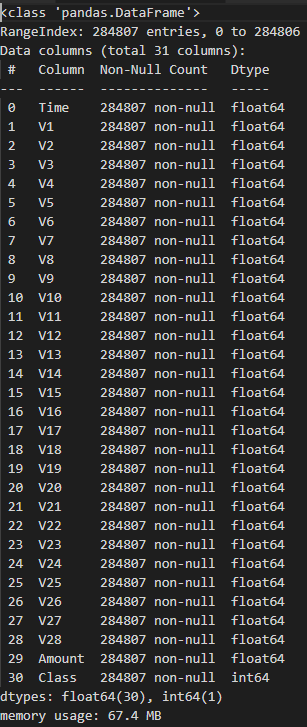

In [3]:
print('(Linhas, Colunas)')
print(f'{df.shape}')

(Linhas, Colunas)
(284807, 31)


In [4]:
print(f'{df.isnull().sum()}')

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Por Extenso:

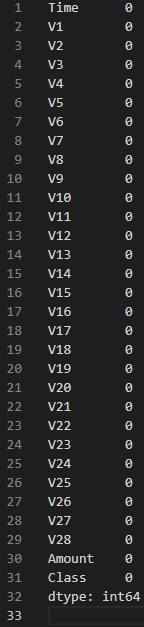

Isso me mostra que:

A base tem 284.807 linhas e 31 colunas. Existem 30 variáveis numéricas e uma variável alvo. As colunas de 'V1' até 'V28' são vetores gerados pelo PCA; 'Time' representa o tempo, em segundos, desde a primeira transação; 'Amount' representa o valor da transação; e 'Class' é a variável alvo, indicando se a transação foi fraude ou não.

Agora, vou analisar o balanceamento da variável alvo.


In [5]:
print(f'{df['Class'].value_counts()}\n')
print(f'{df['Class'].value_counts(normalize=True) * 100}')

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Isso me confirma que a base está extremamente desbalanceada: mais de 280.000 transações não são fraudes e menos de 500 são fraudes.

Isso afeta diretamente a modelagem, tornando métricas como accuracy praticamente inúteis para medir a eficácia do modelo. Se ele classificasse tudo como não fraude, ainda acertaria um número muito alto de casos e, por consequência, teria uma acurácia alta. Isso provaria que o modelo apenas aprendeu a prever tudo como não fraude.


Agora, vou analisar os outros dados da base.

In [6]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


A média de 'Amount' é bem maior que a mediana. Isso indica uma distribuição muito assimétrica à direita, ou seja, a maioria das transações tem valores baixos, mas existem algumas transações com valores extremamente altos, puxando a média para cima.

A variável 'Time' vai de 0 até 172.792 segundos, o que corresponde a aproximadamente 48 horas, ou seja, aos dois dias citados na atividade.

In [7]:
df.groupby('Class')[['Time', 'Amount']].describe()

Time                                                       \
          count          mean           std    min      25%      50%   
Class                                                                  
0      284315.0  94838.202258  47484.015786    0.0  54230.0  84711.0   
1         492.0  80746.806911  47835.365138  406.0  41241.5  75568.5   

                             Amount                                            \
            75%       max     count        mean         std  min   25%    50%   
Class                                                                           
0      139333.0  172792.0  284315.0   88.291022  250.105092  0.0  5.65  22.00   
1      128483.0  170348.0     492.0  122.211321  256.683288  0.0  1.00   9.25   

                         
          75%       max  
Class                    
0       77.05  25691.16  
1      105.89   2125.87

Olhando para a comparação de 'Amount' entre fraude e não fraude, a média das fraudes é maior, mas a mediana das fraudes é menor. Isso me mostra que muitas fraudes acontecem em valores baixos, mas algumas fraudes de valor mais alto puxam a média para cima.

Também posso notar que o valor máximo das transações legítimas é muito maior que o valor máximo das fraudes. Então, não dá para concluir simplesmente que transações maiores são fraude.

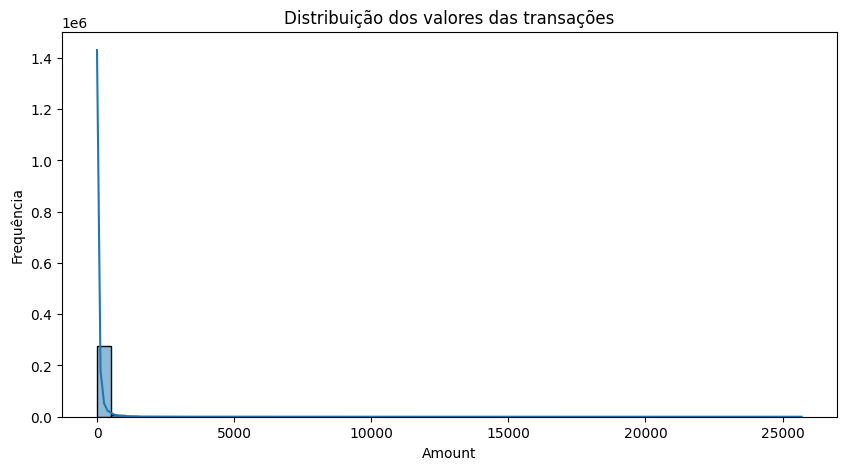

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribuição dos valores das transações')
plt.xlabel('Amount')
plt.ylabel('Frequência')
plt.show()

Como esperado, quase tudo fica concentrado perto de zero, enquanto poucos valores muito altos esticam o eixo até mais de 25 mil.

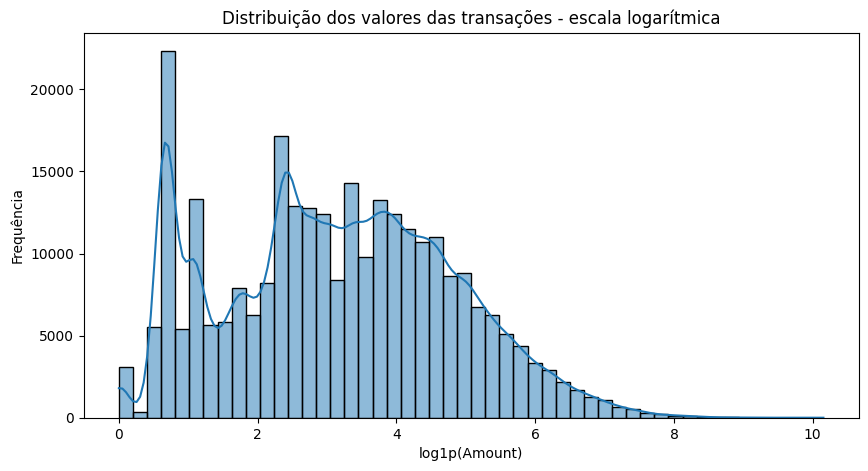

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['Amount']), bins=50, kde=True)
plt.title('Distribuição dos valores das transações - escala logarítmica')
plt.xlabel('log1p(Amount)')
plt.ylabel('Frequência')
plt.show()

Essa versão ficou bem melhor, porque a transformação logarítmica reduziu o impacto dos valores extremos e permitiu visualizar melhor a distribuição.

Ou seja, a variável 'Amount' apresenta forte assimetria à direita. A maior parte das transações possui valores baixos, enquanto poucas transações apresentam valores muito elevados. Isso faz com que a média seja superior à mediana. Por esse motivo, a visualização em escala logarítmica foi útil para reduzir o impacto dos valores extremos e permitir uma análise mais clara da distribuição.

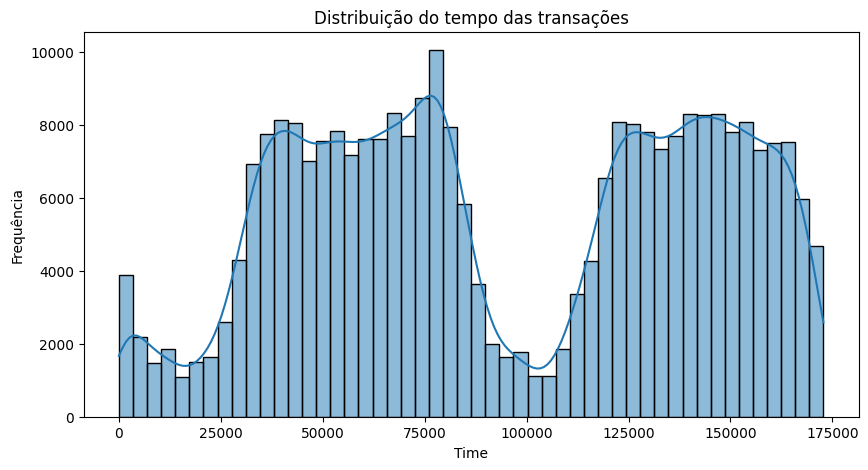

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribuição do tempo das transações')
plt.xlabel('Time')
plt.ylabel('Frequência')
plt.show()

In [11]:
df['Time_hours'] = df['Time'] / 3600

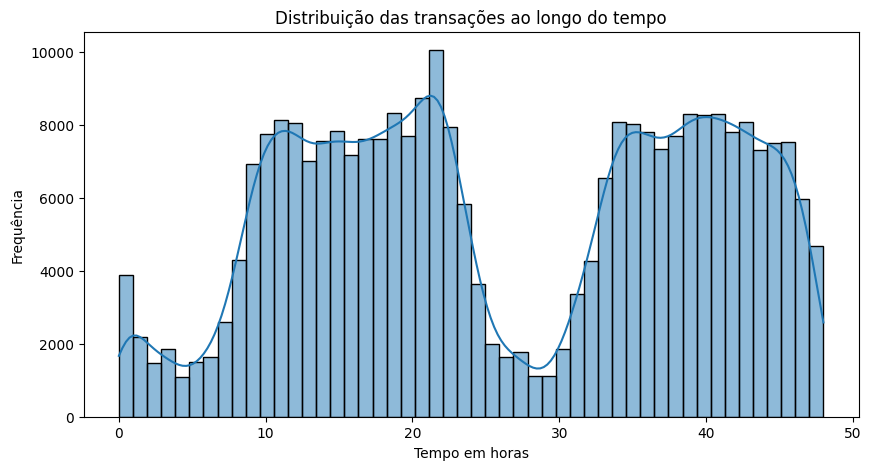

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Time_hours'], bins=50, kde=True)
plt.title('Distribuição das transações ao longo do tempo')
plt.xlabel('Tempo em horas')
plt.ylabel('Frequência')
plt.show()

A distribuição temporal apresenta variações ao longo do período, com maior concentração de transações em determinados intervalos. Isso sugere padrões de atividade ao longo dos dois dias.

In [13]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


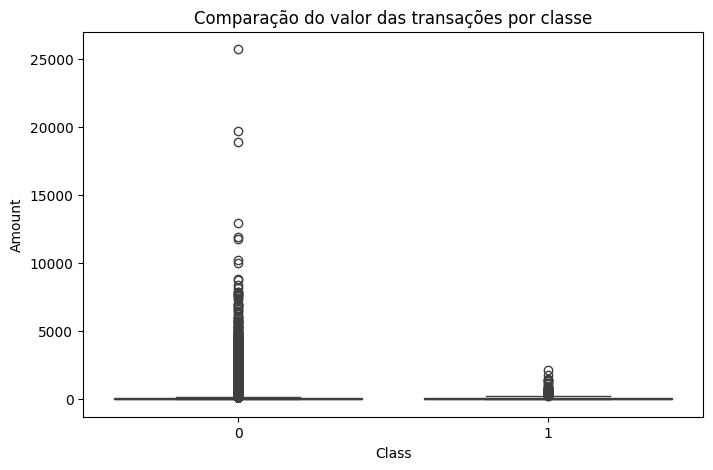

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title('Comparação do valor das transações por classe')
plt.xlabel('Class')
plt.ylabel('Amount')
plt.show()

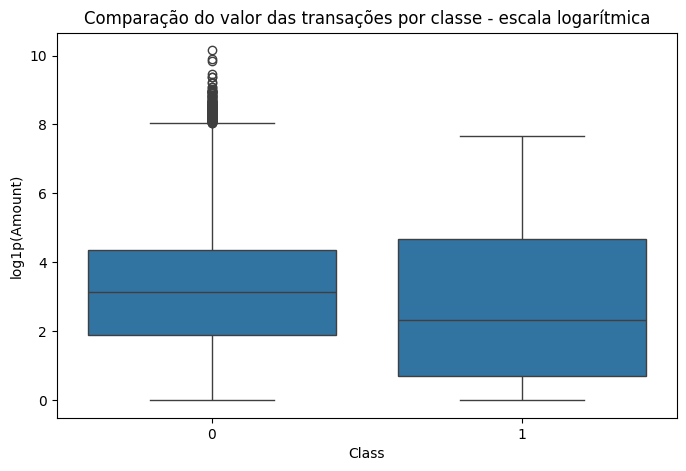

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y=np.log1p(df['Amount']))
plt.title('Comparação do valor das transações por classe - escala logarítmica')
plt.xlabel('Class')
plt.ylabel('log1p(Amount)')
plt.show()

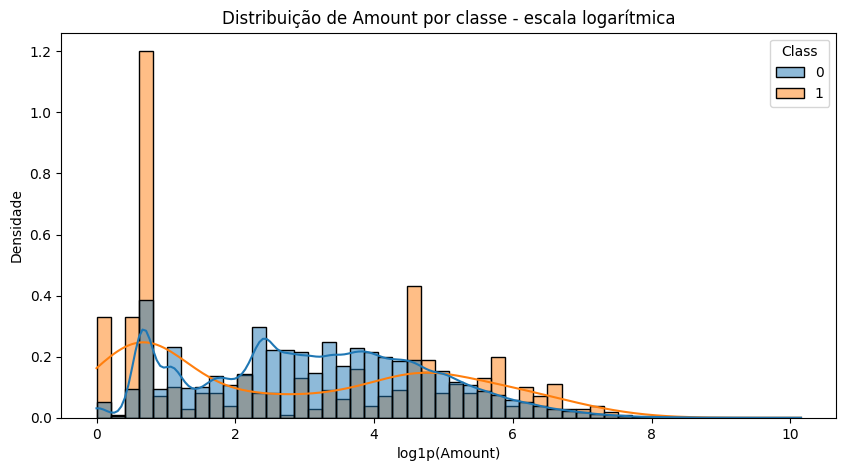

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x=np.log1p(df['Amount']), hue='Class', bins=50, kde=True, stat='density', common_norm=False)
plt.title('Distribuição de Amount por classe - escala logarítmica')
plt.xlabel('log1p(Amount)')
plt.ylabel('Densidade')
plt.show()

In [17]:
df.groupby('Class')['Time_hours'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,26.343945,13.190004,0.000000,15.063889,23.530833,38.703611,47.997778
1,492.0,22.429669,13.287601,0.112778,11.455972,20.991250,35.689722,47.318889


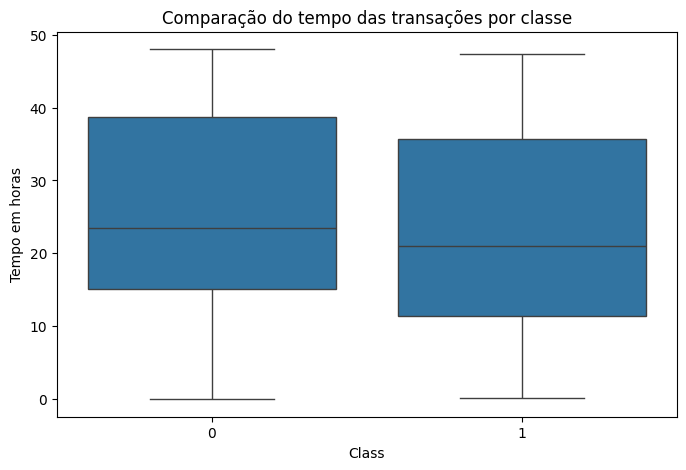

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y='Time_hours')
plt.title('Comparação do tempo das transações por classe')
plt.xlabel('Class')
plt.ylabel('Tempo em horas')
plt.show()

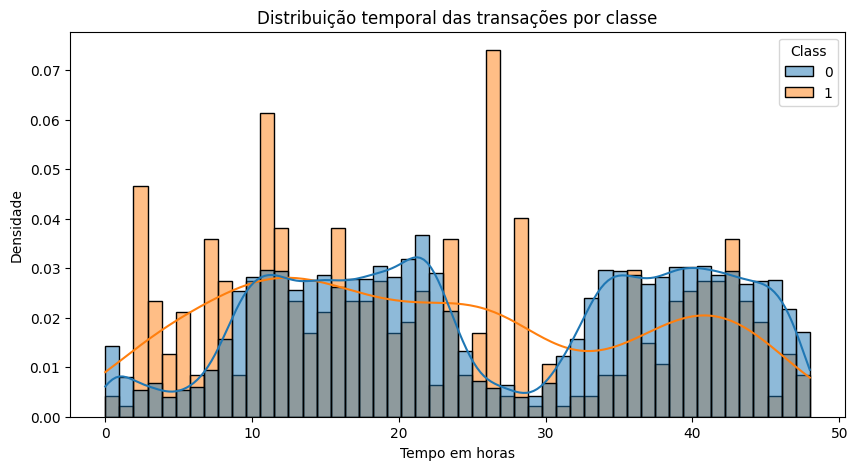

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Time_hours', hue='Class', bins=50, kde=True, stat='density', common_norm=False)
plt.title('Distribuição temporal das transações por classe')
plt.xlabel('Tempo em horas')
plt.ylabel('Densidade')
plt.show()

As fraudes, em média, aconteceram um pouco mais cedo no período analisado, porém a diferença não é enorme. Os boxplots mostraram que existe muita sobreposição entre as classes. Isso significa que 'Time' pode ajudar um pouco, mas não separa as classes sozinho.

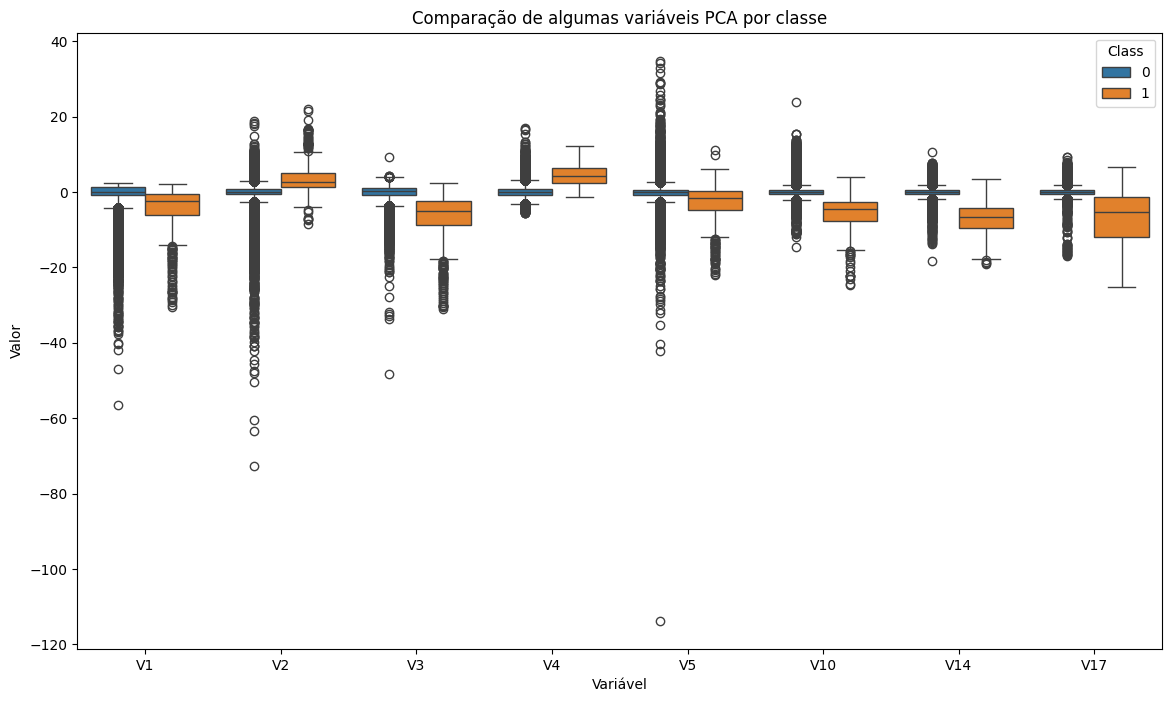

In [20]:
variaveis_v = ['V1', 'V2', 'V3', 'V4', 'V5', 'V10', 'V14', 'V17']

plt.figure(figsize=(14, 8))
df_melt = df.melt(id_vars='Class', value_vars=variaveis_v)

sns.boxplot(data=df_melt, x='variable', y='value', hue='Class')
plt.title('Comparação de algumas variáveis PCA por classe')
plt.xlabel('Variável')
plt.ylabel('Valor')
plt.show()

Os boxplots de algumas variáveis transformadas por PCA mostram diferenças visuais entre transações legítimas e fraudulentas. Variáveis como 'V4', 'V10', 'V14' e 'V17' apresentaram maior separação entre as classes, sugerindo que esses componentes podem ser relevantes para a modelagem.

No entanto, como essas variáveis são componentes de PCA, elas não possuem interpretação direta de negócio.

In [21]:
correlacao_class = df.corr(numeric_only=True)['Class'].sort_values(ascending=False)
correlacao_class

Class         1.000000
V11           0.154876
V4            0.133447
V2            0.091289
V21           0.040413
V19           0.034783
V20           0.020090
V8            0.019875
V27           0.017580
V28           0.009536
Amount        0.005632
V26           0.004455
V25           0.003308
V22           0.000805
V23          -0.002685
V15          -0.004223
V13          -0.004570
V24          -0.007221
Time         -0.012323
Time_hours   -0.012323
V6           -0.043643
V5           -0.094974
V9           -0.097733
V1           -0.101347
V18          -0.111485
V7           -0.187257
V3           -0.192961
V16          -0.196539
V10          -0.216883
V12          -0.260593
V14          -0.302544
V17          -0.326481
Name: Class, dtype: float64

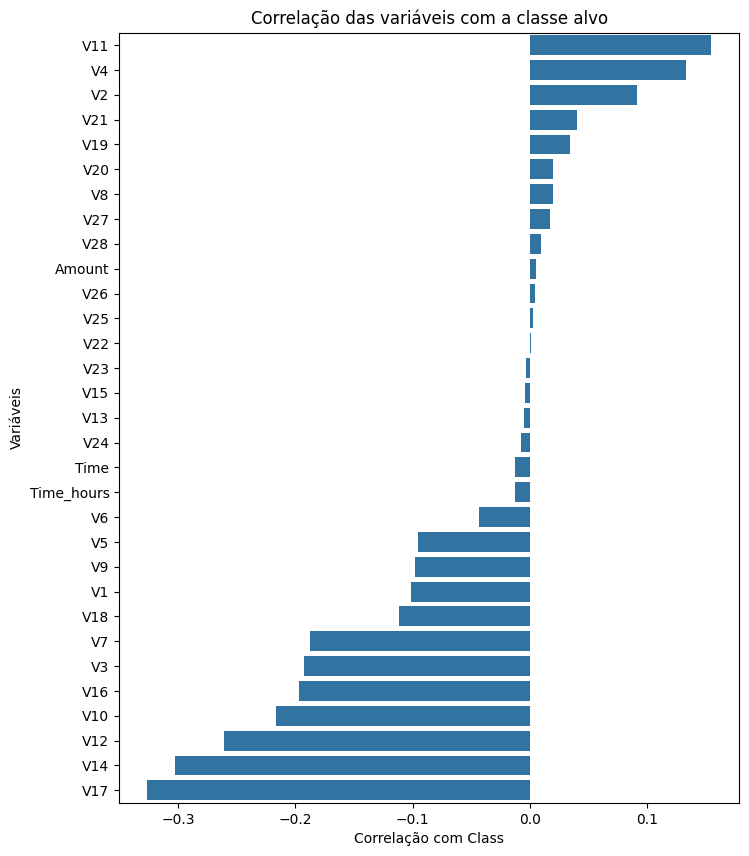

In [22]:
plt.figure(figsize=(8, 10))
sns.barplot(
    x=correlacao_class.drop('Class').values,
    y=correlacao_class.drop('Class').index
)
plt.title('Correlação das variáveis com a classe alvo')
plt.xlabel('Correlação com Class')
plt.ylabel('Variáveis')
plt.show()

A análise de correlação mostrou que algumas variáveis de PCA apresentam maior associação com a classe alvo. As maiores correlações negativas foram observadas em 'V17', 'V14', 'V12', 'V10', 'V16', 'V3' e 'V7', enquanto as maiores correlações positivas apareceram em 'V11', 'V4' e 'V2'.

Isso sugere que esses componentes podem ter maior importância na identificação de fraudes. Ainda assim, como as variáveis são componentes de PCA e a correlação mede apenas relações lineares, essa análise deve ser usada apenas como apoio exploratório, e não como critério definitivo de seleção.

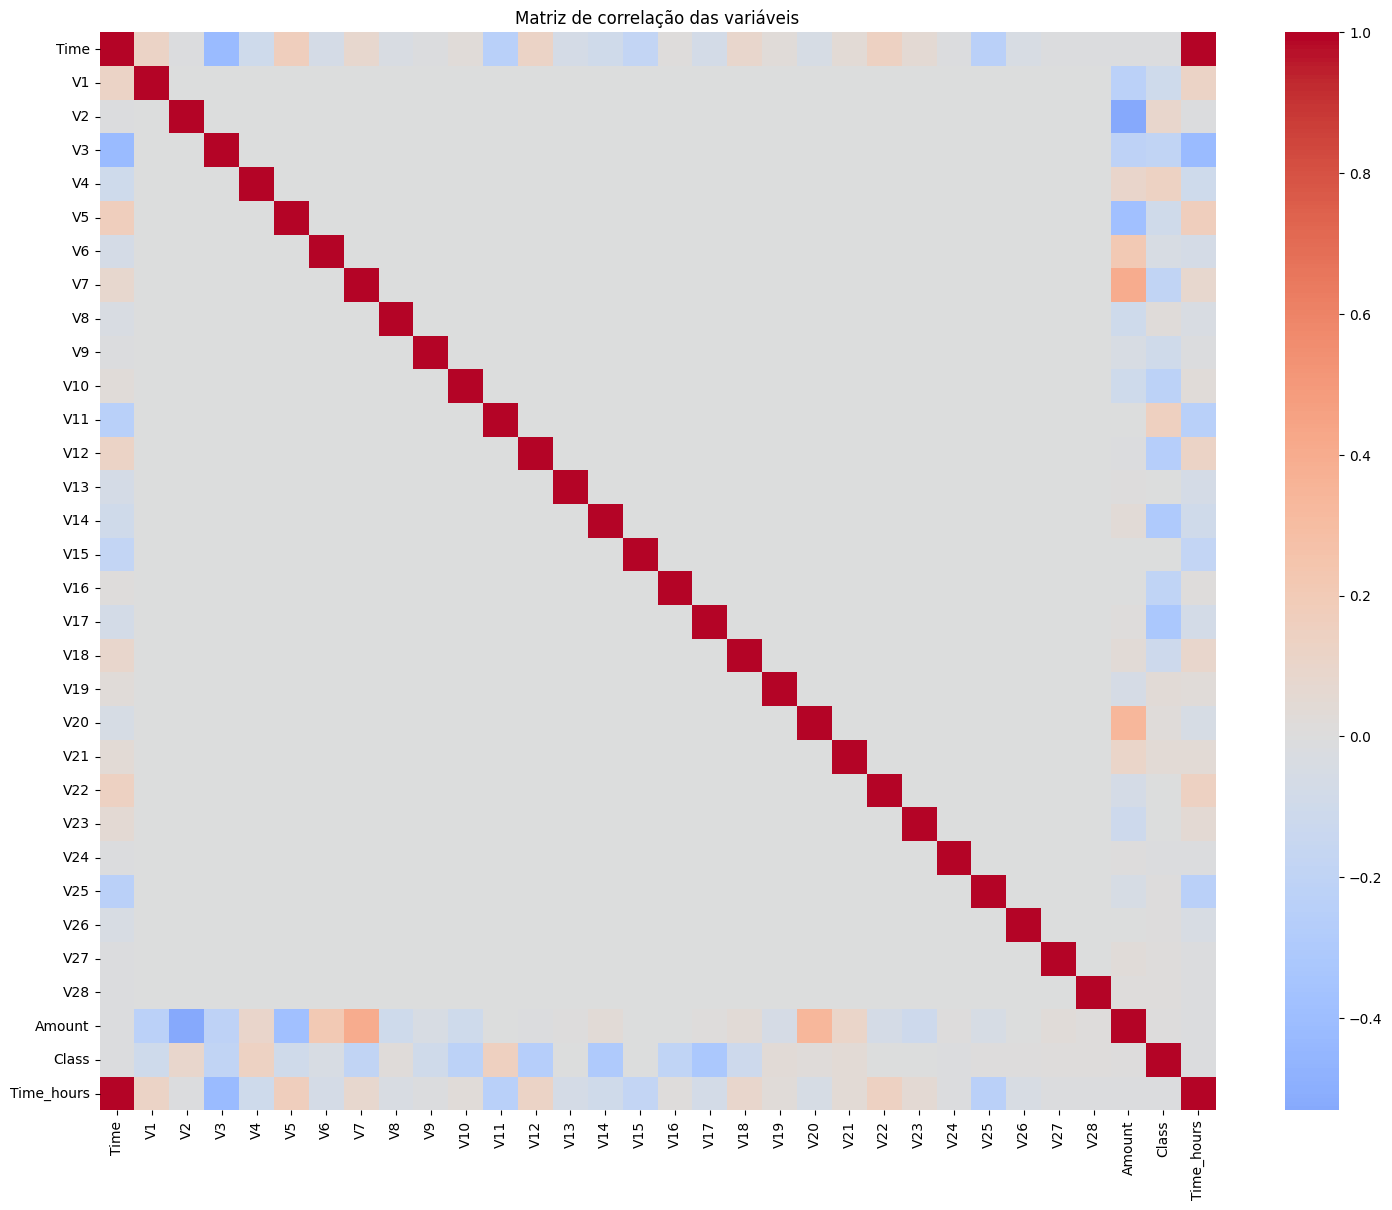

In [23]:
plt.figure(figsize=(18, 14))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Matriz de correlação das variáveis')
plt.show()

Existe correlação perfeita entre 'Time' e 'Time_hours', já que 'Time_hours' é apenas uma transformação direta de 'Time'. Por isso, ambas não devem ser utilizadas simultaneamente na modelagem, para evitar redundância.

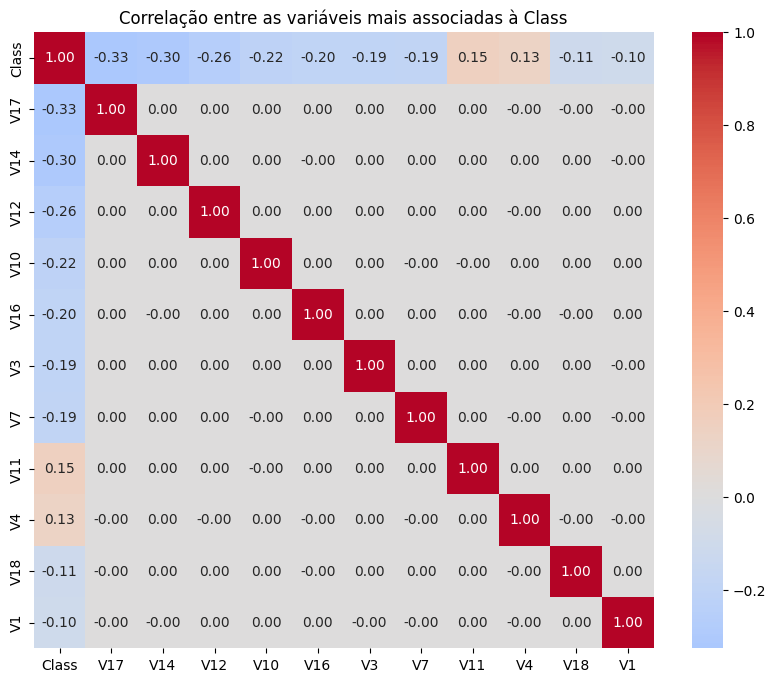

In [24]:
top_corr = correlacao_class.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlação entre as variáveis mais associadas à Class')
plt.show()

A matriz de correlação mostra que os componentes de 'V1' a 'V28' possuem baixa correlação entre si, o que é esperado, pois são variáveis resultantes de PCA.

Em suma, na análise exploratória, observei que a variável 'Amount' possui forte assimetria à direita, com grande concentração de transações de baixo valor e presença de poucos valores extremamente altos. A transformação logarítmica 'log1p(Amount)' ajudou a visualizar melhor essa distribuição. Ao comparar 'Amount' entre as classes, as fraudes apresentaram média maior, mas mediana menor que as transações legítimas, indicando que muitas fraudes ocorrem em valores baixos, embora algumas ocorrências de maior valor elevem a média da classe fraudulenta.

A variável 'Time', convertida para horas, mostrou que a base cobre aproximadamente dois dias de transações. As fraudes ocorreram, em média, um pouco mais cedo que as transações legítimas, mas houve grande sobreposição entre as distribuições, indicando que o tempo, isoladamente, não é suficiente para separar as classes.

Também analisei algumas variáveis 'V', que representam componentes gerados por PCA. Os boxplots indicaram diferenças relevantes entre as classes em variáveis como 'V4', 'V10', 'V14' e 'V17'. A análise de correlação reforçou esse ponto, mostrando que 'V17', 'V14', 'V12', 'V10', 'V16', 'V3' e 'V7' possuem as maiores correlações negativas com a classe fraude, enquanto 'V11', 'V4' e 'V2' apresentaram as maiores correlações positivas.

Apesar desses indícios, é importante destacar que as variáveis 'V' não possuem interpretação direta de negócio por serem componentes de PCA. Além disso, a correlação mede apenas relações lineares. Portanto, a análise exploratória indica possíveis variáveis relevantes, mas a definição do melhor conjunto de variáveis e do melhor modelo deve ser feita por meio da etapa de modelagem e avaliação com métricas adequadas para dados desbalanceados.

Agora, vou realizar um leve tratamento nos dados.

Como já sei que não existem valores nulos, posso pular essa etapa. Agora, vou verificar se há registros duplicados na base.

In [25]:
df.duplicated().sum()

np.int64(1081)

Observei que existem valores duplicados, porém prefiro manter esses registros, pois, em um contexto de transações financeiras, podem ocorrer operações muito semelhantes. Além disso, a base não possui um identificador único que permita confirmar se são duplicidades reais.

A variável 'Time', originalmente representada em segundos, foi convertida para horas, criando a variável 'Time_hours'. Essa transformação facilita a interpretação do período analisado, já que a base cobre aproximadamente 48 horas de transações. Como 'Time_hours' é uma transformação direta de 'Time', a variável original foi removida para evitar redundância no modelo.

Como a variável 'Amount' apresentou forte assimetria à direita, com grande concentração de valores baixos e presença de valores extremos, foi criada a variável 'Amount_log' utilizando a transformação 'log1p'. Essa transformação reduz o impacto dos outliers e torna a distribuição mais adequada para a criação de modelos. Após a criação de 'Amount_log', a variável original 'Amount' foi removida para evitar redundância.

In [26]:
df['Time_hours'] = df['Time'] / 3600
df['Amount_log'] = np.log1p(df['Amount'])

df = df.drop(columns=['Time', 'Amount'])

Após a criação das variáveis 'Amount_log' e 'Time_hours', realizei uma nova análise descritiva para verificar se as transformações foram aplicadas corretamente e para observar a distribuição geral dessas novas variáveis.

A variável 'Amount_log' foi criada a partir de 'Amount', usando 'log1p', com o objetivo de reduzir a assimetria causada por valores extremos. Já 'Time_hours' foi criada a partir de 'Time', convertendo os segundos para horas e facilitando a interpretação do período analisado.

In [27]:
df[['Amount_log', 'Time_hours']].describe()

,Amount_log,Time_hours
count,284807.000000,284807.000000
mean,3.152188,26.337183
std,1.656648,13.191152
min,0.000000,0.000000
25%,1.887070,15.055972
50%,3.135494,23.525556
75%,4.358822,38.700139
max,10.153941,47.997778


Após as transformações, foi possível observar que 'Amount_log' apresenta uma distribuição mais controlada em relação à variável original 'Amount', reduzindo o impacto dos valores extremos. A proximidade entre média e mediana indica que a transformação logarítmica ajudou a suavizar a assimetria da variável.

A variável 'Time_hours', por sua vez, varia de 0 a aproximadamente 48 horas, confirmando que o conjunto de dados cobre dois dias de transações.

Essas variáveis serão utilizadas no lugar de 'Amount' e 'Time' para evitar redundância e melhorar a preparação dos dados para a modelagem.

Agora, vou separar as bases de treino e teste.

In [28]:
x = df.drop(columns=['Class'])
y = df['Class']

In [29]:
print('Formato de X:', x.shape)
print('Formato de y:', y.shape)
print('\nColunas utilizadas no modelo:')
print(x.columns)

Formato de X: (284807, 30)
Formato de y: (284807,)

Colunas utilizadas no modelo:
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Time_hours',
       'Amount_log'],
      dtype='str')


O conjunto 'X' ficou composto por 284.807 registros e 30 variáveis explicativas. Já o vetor 'y' ficou com 284.807 registros, contendo apenas a classe da transação.

As variáveis utilizadas no modelo foram os componentes de 'V1' a 'V28', além de 'Time_hours' e 'Amount_log'.

In [30]:
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Formato x_treino:', x_treino.shape)
print('Formato x_teste:', x_teste.shape)
print('Formato y_treino:', y_treino.shape)
print('Formato y_teste:', y_teste.shape)

Formato x_treino: (227845, 30)
Formato x_teste: (56962, 30)
Formato y_treino: (227845,)
Formato y_teste: (56962,)


In [31]:
print('Distribuição do y_train:')
print(y_treino.value_counts())
print(y_treino.value_counts(normalize=True) * 100)

print('\nDistribuição do y_test:')
print(y_teste.value_counts())
print(y_teste.value_counts(normalize=True) * 100)

Distribuição do y_train:
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64

Distribuição do y_test:
Class
0    56864
1       98
Name: count, dtype: int64
Class
0    99.827955
1     0.172045
Name: proportion, dtype: float64


A divisão gerou 227.845 registros para treino e 56.962 registros para teste. A distribuição das classes foi preservada nos dois conjuntos: no treino, as fraudes representam aproximadamente 0,173% dos dados, enquanto no teste representam aproximadamente 0,172%.

Isso confirma que a separação estratificada foi aplicada corretamente, mantendo o desbalanceamento original da base e permitindo uma avaliação mais realista do modelo.

Vou usar primeiramente regressão logística como modelo, para observar como os dados se comportam com um modelo menos complexo em relação a modelos como 'Random Forest', 'XGBoost' ou 'SVM'.

Vou primeiro padronizar 'Time_hours' e 'Amount_log', já que a regressão logística é bastante sensível à escala das variáveis.

In [32]:
scaler = StandardScaler()

x_treino_scaled = x_treino.copy()
x_teste_scaled = x_teste.copy()

colunas_escalar = ['Time_hours', 'Amount_log']

x_treino_scaled[colunas_escalar] = scaler.fit_transform(x_treino[colunas_escalar])
x_teste_scaled[colunas_escalar] = scaler.transform(x_teste[colunas_escalar])

Agora, vou treinar o modelo.

In [33]:
modelo_reglog = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_reglog.fit(x_treino_scaled, y_treino)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Agora, vou fazer algumas previsões.


In [34]:
y_pred_reglog = modelo_reglog.predict(x_teste_scaled)

e avaliar o modelo

In [35]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_reglog))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_reglog))

print('Accuracy:', accuracy_score(y_teste, y_pred_reglog))
print('Recall:', recall_score(y_teste, y_pred_reglog))
print('Precision:', precision_score(y_teste, y_pred_reglog))
print('F1-score:', f1_score(y_teste, y_pred_reglog))

Matriz de confusão:
[[56851    13]
 [   37    61]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.62      0.71        98

    accuracy                           1.00     56962
   macro avg       0.91      0.81      0.85     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9991222218320986
Recall: 0.6224489795918368
Precision: 0.8243243243243243
F1-score: 0.7093023255813954


Resultados interessantes. Eles mostram que o modelo ainda não é suficiente como modelo final para detecção de fraudes.

A matriz de confusão mostra que o modelo encontrou 61 das 98 fraudes reais no teste, gerando um recall de 62%. Essa métrica representa a porcentagem de fraudes que o modelo conseguiu detectar. No entanto, ele deixou passar 37 fraudes, que é o ponto mais preocupante para um modelo detector de fraudes.

A acurácia, como esperado, foi alta, porque eu já imaginava que o forte desbalanceamento da base influenciaria essa métrica. Nesse caso, as métricas mais importantes são recall e precision. O recall indica que o modelo capturou uma parte significativa das fraudes, enquanto a precision, relativamente alta, de 82%, indica que, quando o modelo classificou uma transação como fraude, ele acertou 82% das vezes.


Vou fazer uma regressão logística com 'class_weight=balanced', porque quero verificar se o aumento da atenção à classe minoritária no modelo melhora a detecção de fraudes e reduz a quantidade de falsos negativos.


In [36]:
modelo_reglog_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

modelo_reglog_balanced.fit(x_treino_scaled, y_treino)

y_pred_reglog_balanced = modelo_reglog_balanced.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_reglog_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_reglog_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_reglog_balanced))
print('Recall:', recall_score(y_teste, y_pred_reglog_balanced))
print('Precision:', precision_score(y_teste, y_pred_reglog_balanced))
print('F1-score:', f1_score(y_teste, y_pred_reglog_balanced))

Matriz de confusão:
[[55458  1406]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Accuracy: 0.9751764334117482
Recall: 0.9183673469387755
Precision: 0.06016042780748663
F1-score: 0.11292346298619825


Consegui obter um aumento no recall de 62,24% para 91,84%, indicando que o modelo identificou corretamente 90 das 98 fraudes no conjunto de teste. Porém, esse ganho veio acompanhado de um aumento nos falsos positivos, em que o modelo classificou 1.406 transações como fraude, reduzindo a precision para 6%. Isso indica que o modelo se tornou mais sensível para detectar fraudes, mas também passou a gerar muitos alertas incorretos.

Com isso, o modelo apresentou melhor desempenho em recall, mas pior desempenho em precision. Em um contexto real, esse modelo cumpriria melhor o objetivo de evitar fraudes reais, porém o custo dos falsos positivos atrapalharia seu funcionamento, exigindo revisões manuais e autenticações adicionais para evitar bloqueios indevidos.


Vou criar um dataframe para guardar os resultados dos meus modelos e compará-los de uma forma melhor.


In [37]:
resultados = []

def salvar_resultados(nome_modelo, y_real, y_pred): # uma função para facilitar salvar os resultados
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    
    resultados.append({
        'Modelo': nome_modelo,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred),
        'F1-score': f1_score(y_real, y_pred),
        'Verdadeiros Negativos': tn,
        'Falsos Positivos': fp,
        'Falsos Negativos': fn,
        'Verdadeiros Positivos': tp
    })

In [38]:
salvar_resultados('Regressão Logística', y_teste, y_pred_reglog)

salvar_resultados('Regressão Logística Balanced', y_teste, y_pred_reglog_balanced)

In [39]:
resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90


Agora, vou testar um modelo de 'Random Forest'.


In [40]:
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_random_forest.fit(x_treino, y_treino)

y_pred_random_forest = modelo_random_forest.predict(x_teste)

Agora, vou avaliar o modelo.


In [41]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_random_forest))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_random_forest))

print('Accuracy:', accuracy_score(y_teste, y_pred_random_forest))
print('Recall:', recall_score(y_teste, y_pred_random_forest))
print('Precision:', precision_score(y_teste, y_pred_random_forest))
print('F1-score:', f1_score(y_teste, y_pred_random_forest))

Matriz de confusão:
[[56860     4]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9996137776061234
Recall: 0.8163265306122449
Precision: 0.9523809523809523
F1-score: 0.8791208791208791


Com isso, posso dizer que o 'Random Forest' sem balanceamento teve o melhor equilíbrio até o momento, pois detectou mais fraudes e gerou menos falsos positivos, apresentando um 'F1-score' maior, o que mostra um melhor equilíbrio entre 'precision' e 'recall'.

Ele identificou 80 das 98 fraudes presentes no conjunto de teste, com um 'recall' de aproximadamente 82% e uma 'precision' de 95%, indicando que a maioria das transações classificadas como fraude realmente eram fraudes.

A matriz de confusão mostrou 4 falsos positivos, um número muito inferior ao da regressão logística balanceada, que gerou 1.406 falsos positivos. Porém, este modelo ainda deixou passar 18 fraudes reais, enquanto a regressão logística balanceada deixou passar apenas 8. Ou seja, o 'Random Forest' teve um melhor equilíbrio geral entre detecção de fraudes e controle de falsos alarmes. Ainda assim, com alguns ajustes, posso tentar reduzir os falsos negativos, além de ele ser, até o momento, o modelo com melhor 'F1-score'.


In [42]:
salvar_resultados('Random Forest', y_teste, y_pred_random_forest)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80


Agora, vou testar um 'Random Forest' com 'class_weight=balanced'.


In [43]:
modelo_random_forest_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

modelo_random_forest_balanced.fit(x_treino, y_treino)

y_pred_random_forest_balanced = modelo_random_forest_balanced.predict(x_teste)

Agora, vou avaliar o modelo.


In [44]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_random_forest_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_random_forest_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_random_forest_balanced))
print('Recall:', recall_score(y_teste, y_pred_random_forest_balanced))
print('Precision:', precision_score(y_teste, y_pred_random_forest_balanced))
print('F1-score:', f1_score(y_teste, y_pred_random_forest_balanced))

Matriz de confusão:
[[56857     7]
 [   19    79]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.81      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9995435553526912
Recall: 0.8061224489795918
Precision: 0.9186046511627907
F1-score: 0.8586956521739131


O 'class_weight=balanced' mostrou uma leve piora do modelo. Ele identificou 79 das 98 fraudes presentes no conjunto de teste, deixando passar 19 fraudes reais, enquanto o 'Random Forest' sem balanceamento deixou passar apenas 18.

Além disso, os falsos positivos aumentaram de 4 para 7, e a 'precision' caiu de 95% para 91%, assim como o 'recall', que caiu de 81% para 80%.


In [45]:
salvar_resultados(
    'Random Forest Balanced',
    y_teste,
    y_pred_random_forest_balanced
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79


Agora, vou testar um modelo 'XGBoost' sem balanceamento.


In [46]:
modelo_xgboost = XGBClassifier(
    n_estimators=100, # define a quantidade de arvores que o modelo ira criar, escolhemos 100 porque é um valor não tao baixo ao ponto de ficar fraco e nem tão alto ao ponto de ficar muito demorado ou propenso a overfitting
    max_depth=6, # define a profundidade maxima da arvore, sendo 6 um ponto inicial razoavel fazendo divisões complexas porem ainda com algum controle
    learning_rate=0.1, # Define o quanto cada nova arvore influencia o modelo final, 0.1 é um valor inicialcomum que cria um modelo que aprende de forma estavel sem ficar lento
    random_state=42,
    n_jobs=-1, # define quantos nucleos o xgboost pode usar, e estamos dizendo para o modelo usar todos os nucleos acelerando o treinamento
    eval_metric='logloss' # define a metrica interna usada pelo xgboost para avaliar o erro durante o treinamento, sendo logloss uma metrica comum para classificação probabilistica, penalizando previsões muito consfiantes quando estão erradas
) # usei esses parametros como uma configuração inicial segura

modelo_xgboost.fit(x_treino, y_treino)

y_pred_xgboost = modelo_xgboost.predict(x_teste)

agora, avaliando o modelo.

In [47]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_xgboost))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_xgboost))

print('Accuracy:', accuracy_score(y_teste, y_pred_xgboost))
print('Recall:', recall_score(y_teste, y_pred_xgboost))
print('Precision:', precision_score(y_teste, y_pred_xgboost))
print('F1-score:', f1_score(y_teste, y_pred_xgboost))

Matriz de confusão:
[[56857     7]
 [   22    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9994908886626171
Recall: 0.7755102040816326
Precision: 0.9156626506024096
F1-score: 0.8397790055248618


Isso me permite concluir que o 'XGBoost' sem balanceamento apresentou um desempenho consistente, porém inferior ao 'Random Forest' sem balanceamento, principalmente considerando a detecção das fraudes reais.

Isso mostra que, apesar de promissor, ele ainda precisa de ajustes para lidar melhor com a base.


In [48]:
salvar_resultados(
    'XGBoost',
    y_teste,
    y_pred_xgboost
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76


Agora, vou lidar com o 'XGBoost' balanceado.

In [49]:
qtd_classe_0 = y_treino.value_counts()[0]
qtd_classe_1 = y_treino.value_counts()[1]

scale_pos_weight = qtd_classe_0 / qtd_classe_1

scale_pos_weight

np.float64(577.2868020304569)

Fiz isso para compensar o desbalanceamento entre as classes. Como a classe fraude é muito menor que a classe legítima, o 'XGBoost' precisa atribuir maior peso aos erros cometidos na classe minoritária.

Agora, vou treinar o modelo.


In [50]:
modelo_xgboost_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

modelo_xgboost_balanced.fit(x_treino, y_treino)

y_pred_xgboost_balanced = modelo_xgboost_balanced.predict(x_teste)

avaliando o modelo

In [51]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_xgboost_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_xgboost_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_xgboost_balanced))
print('Recall:', recall_score(y_teste, y_pred_xgboost_balanced))
print('Precision:', precision_score(y_teste, y_pred_xgboost_balanced))
print('F1-score:', f1_score(y_teste, y_pred_xgboost_balanced))

Matriz de confusão:
[[56838    26]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.84      0.80        98

    accuracy                           1.00     56962
   macro avg       0.88      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9992626663389628
Recall: 0.8367346938775511
Precision: 0.7592592592592593
F1-score: 0.7961165048543689


Isso me permite concluir que o balanceamento no 'XGBoost' apresentou melhora na detecção de fraudes em relação ao 'XGBoost' sem balanceamento. O 'recall' aumentou de 77% para 83%, e os falsos negativos foram reduzidos de 22 para 16, indicando que o modelo se tornou mais sensível à classe minoritária com o ajuste realizado.

Porém, esse ganho veio acompanhado de uma queda na métrica 'precision', que passou de 91% para 75%, além de um aumento nos falsos positivos, que passaram de 7 para 26.

Em suma, o modelo reduziu o número de fraudes não detectadas, mas gerou mais alertas incorretos.


In [52]:
salvar_resultados(
    'XGBoost Balanced',
    y_teste,
    y_pred_xgboost_balanced
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82


Agora, vou testar um modelo 'SVM' sem balanceamento.


In [53]:
modelo_svm = SVC(
    kernel='linear',
    C=1.0,
    gamma='scale',
    random_state=42
)

modelo_svm.fit(x_treino_scaled, y_treino)

y_pred_svm = modelo_svm.predict(x_teste_scaled)

Avaliando o modelo

In [54]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_svm))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_svm))

print('Accuracy:', accuracy_score(y_teste, y_pred_svm))
print('Recall:', recall_score(y_teste, y_pred_svm))
print('Precision:', precision_score(y_teste, y_pred_svm))
print('F1-score:', f1_score(y_teste, y_pred_svm))

Matriz de confusão:
[[56843    21]
 [   19    79]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.81      0.80        98

    accuracy                           1.00     56962
   macro avg       0.89      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9992977774656788
Recall: 0.8061224489795918
Precision: 0.79
F1-score: 0.797979797979798


Posso analisar que o 'SVM Linear' sem balanceamento detectou 79 das 98 fraudes. Comparado com o 'Random Forest', apresentou desempenho inferior, pois deixou passar uma fraude a mais e gerou mais falsos positivos.


In [55]:
salvar_resultados(
    'SVM Linear',
    y_teste,
    y_pred_svm
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79


Agora, vou testar o 'SVM Linear' com balanceamento.


In [56]:
modelo_svm_balanced = SVC(
    kernel='linear',
    C=1.0,
    gamma='scale',
    random_state=42,
    class_weight='balanced'
)

modelo_svm_balanced.fit(x_treino_scaled, y_treino)

y_pred_svm_balanced = modelo_svm_balanced.predict(x_teste_scaled)

vou avaliar o modelo

In [57]:
print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_svm_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_svm_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_svm_balanced))
print('Recall:', recall_score(y_teste, y_pred_svm_balanced))
print('Precision:', precision_score(y_teste, y_pred_svm_balanced))
print('F1-score:', f1_score(y_teste, y_pred_svm_balanced))

Matriz de confusão:
[[55453  1411]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Accuracy: 0.975088655594958
Recall: 0.9183673469387755
Precision: 0.05996002664890073
F1-score: 0.1125703564727955


Posso ver que o 'SVM Linear' com balanceamento apresentou um 'recall' maior que o modelo anterior, reduzindo o número de falsos negativos para apenas 8.

Porém, houve um aumento expressivo dos falsos positivos, chegando a 1.411 transações legítimas classificadas como fraude. Com isso, a 'precision' foi reduzida para aproximadamente 6%, mostrando que o modelo gera muitos alertas incorretos.


In [58]:
salvar_resultados(
    'SVM Linear Balanced',
    y_teste,
    y_pred_svm_balanced
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79
7,SVM Linear Balanced,0.975089,0.918367,0.059960,0.112570,55453,1411,8,90


Agora, vou usar cross-validation para verificar quais modelos mantêm a consistência.

Os modelos escolhidos são:

'Random Forest': melhor equilíbrio geral com as minhas métricas principais.

'Random Forest Balanced': o cross-validation vai me permitir confirmar se a piora realmente ocorreu de forma consistente ou se foi específica da divisão entre treino e teste.

'XGBoost': mesmo sem balanceamento, apresentou um bom desempenho geral e serve como comparação importante em relação ao 'Random Forest'.

'XGBoost Balanced': como o objetivo principal do problema é minimizar fraudes não detectadas, esse modelo é relevante para avaliar se o uso de 'scale_pos_weight' melhora de forma consistente a sensibilidade à classe fraude.

Mantive o 'SVM' de fora devido ao alto custo computacional observado até agora. Vejo seu uso como contraproducente neste momento, já que ele não superou nem o 'Random Forest' nem o 'XGBoost' em equilíbrio geral, tanto nas versões básicas quanto nas balanceadas. Talvez, com ajuste de hiperparâmetros, o desempenho pudesse melhorar, porém isso aumentaria o custo computacional na maioria dos casos. Por isso, por enquanto, não vejo essa abordagem como produtiva para este projeto. Talvez ela fosse mais adequada em um projeto mais profissional, com uma máquina de maior poder computacional.


In [59]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Cross-validation do 'Random Forest' sem balanceamento.


In [60]:
modelo_rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [61]:
scoring = ['accuracy', 'recall', 'precision', 'f1']

scores_rf = cross_validate(
    modelo_rf_cv,
    x_treino,
    y_treino,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

Agora, vou avaliar o modelo

In [62]:
resultados_rf_cv = pd.DataFrame({
    'Métrica': ['Accuracy', 'Recall', 'Precision', 'F1-score'],
    'Média': [
        scores_rf['test_accuracy'].mean(),
        scores_rf['test_recall'].mean(),
        scores_rf['test_precision'].mean(),
        scores_rf['test_f1'].mean()
    ]
})

resultados_rf_cv

,Métrica,Média
0,Accuracy,0.999522
1,Recall,0.771535
2,Precision,0.942889
3,F1-score,0.848026


In [63]:
y_pred_rf_cv = cross_val_predict(
    modelo_rf_cv,
    x_treino,
    y_treino,
    cv=cv,
    n_jobs=1
)

matriz_rf_cv = confusion_matrix(y_treino, y_pred_rf_cv)

matriz_rf_cv

array([[227432,     19],
       [    90,    304]])

Posso concluir que a cross-validation no 'Random Forest' sem balanceamento apresentou resultados consistentes, com acurácia média de 99%, 'precision' média de 94%, 'recall' médio de 77% e 'F1-score' médio de 84%.

A matriz mostrou que o modelo identificou 304 das 394 fraudes presentes no conjunto de treino, deixando passar 90 fraudes. Isso significa que o 'Random Forest' mantém bom desempenho mesmo quando avaliado em diferentes divisões dos dados, principalmente considerando a alta 'precision' e o baixo número de falsos positivos.

Apesar disso, ainda existe margem para melhorar a detecção de fraudes e reduzir os falsos negativos, levando em conta que o 'recall' médio da validação cruzada ficou abaixo do 'recall' observado no teste final.


Agora, vou criar uma função para salvar apenas os resultados da cross-validation.


In [64]:
resultados_cv = []

In [65]:
def salvar_resultados_cv(nome_modelo, y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    
    resultados_cv.append({
        'Modelo': nome_modelo,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'F1-score': f1_score(y_real, y_pred, zero_division=0),
        'Verdadeiros Negativos': tn,
        'Falsos Positivos': fp,
        'Falsos Negativos': fn,
        'Verdadeiros Positivos': tp
    })

In [66]:
salvar_resultados_cv(
    'Random Forest Cross-Validation',
    y_treino,
    y_pred_rf_cv
)

resultados_cv_modelos = pd.DataFrame(resultados_cv)
resultados_cv_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest Cross-Validation,0.999522,0.771574,0.941176,0.847978,227432,19,90,304


Cross-validation do 'Random Forest' com balanceamento.


In [67]:
modelo_rf_balanced_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

In [68]:
scoring = ['accuracy', 'recall', 'precision', 'f1']

scores_rf_balanced = cross_validate(
    modelo_rf_balanced_cv,
    x_treino,
    y_treino,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

agora, vou avaliar o modelo

In [69]:
resultados_rf_balanced_cv = pd.DataFrame({
    'Métrica': ['Accuracy', 'Recall', 'Precision', 'F1-score'],
    'Média': [
        scores_rf_balanced['test_accuracy'].mean(),
        scores_rf_balanced['test_recall'].mean(),
        scores_rf_balanced['test_precision'].mean(),
        scores_rf_balanced['test_f1'].mean()
    ]
})

resultados_rf_balanced_cv

,Métrica,Média
0,Accuracy,0.999504
1,Recall,0.779195
2,Precision,0.923911
3,F1-score,0.844258


In [70]:
y_pred_rf_balanced_cv = cross_val_predict(
    modelo_rf_balanced_cv,
    x_treino,
    y_treino,
    cv=cv,
    n_jobs=1
)

matriz_rf_balanced_cv = confusion_matrix(y_treino, y_pred_rf_balanced_cv)

matriz_rf_balanced_cv

array([[227425,     26],
       [    87,    307]])

Posso concluir que o cross-validation do 'Random Forest' balanceado apresentou um pequeno aumento no 'recall' em relação ao 'Random Forest' sem balanceamento, passando de 77,1% para 77,9%. Também houve uma redução nos falsos negativos, de 90 para 87, indicando que o modelo balanceado identificou algumas fraudes adicionais.

Porém, isso foi acompanhado de uma queda na 'precision' de cerca de 2% e pelo aumento dos falsos positivos, que passaram de 19 para 26. Além disso, o 'F1-score' caiu de 84,80% para 84,46%. Assim, houve uma melhora discreta na redução de fraudes não detectadas, mas não o suficiente para superar o modelo sem balanceamento em equilíbrio geral.

Com isso, posso dizer que o 'Random Forest' sem balanceamento foi o modelo mais preciso e com melhor 'F1-score', enquanto o 'Random Forest' com balanceamento pode ser considerado caso a prioridade seja reduzir os falsos negativos, mesmo com o aumento dos falsos positivos.


In [71]:
salvar_resultados_cv(
    'Random Forest Balanced Cross-Validation',
    y_treino,
    y_pred_rf_balanced_cv
)

resultados_cv_modelos = pd.DataFrame(resultados_cv)
resultados_cv_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest Cross-Validation,0.999522,0.771574,0.941176,0.847978,227432,19,90,304
1,Random Forest Balanced Cross-Validation,0.999504,0.779188,0.921922,0.844567,227425,26,87,307


Cross-validation do 'XGBoost' sem balanceamento.


In [72]:
modelo_xgb_cv = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


In [73]:
scoring = ['accuracy', 'recall', 'precision', 'f1']

scores_xgb = cross_validate(
    modelo_xgb_cv,
    x_treino,
    y_treino,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

agora, vou avaliar o modelo

In [74]:
resultados_xgb_cv = pd.DataFrame({
    'Métrica': ['Accuracy', 'Recall', 'Precision', 'F1-score'],
    'Média': [
        scores_xgb['test_accuracy'].mean(),
        scores_xgb['test_recall'].mean(),
        scores_xgb['test_precision'].mean(),
        scores_xgb['test_f1'].mean()
    ]
})

resultados_xgb_cv

,Métrica,Média
0,Accuracy,0.999473
1,Recall,0.746316
2,Precision,0.939910
3,F1-score,0.829729


In [75]:
y_pred_xgb_cv = cross_val_predict(
    modelo_xgb_cv,
    x_treino,
    y_treino,
    cv=cv,
    n_jobs=1
)

matriz_xgb_cv = confusion_matrix(y_treino, y_pred_xgb_cv)

matriz_xgb_cv

array([[227431,     20],
       [   100,    294]])

Com isso, posso concluir que o 'XGBoost' sem balanceamento apresentou acurácia média de 99%, 'precision' média de 93%, 'recall' médio de 74% e 'F1-score' médio de 82%. Isso indica que o modelo possui boa precisão ao identificar fraudes, mas ainda deixa passar uma quantidade relevante de casos fraudulentos.

Pela matriz, posso ver que o modelo identificou 294 das 394 fraudes presentes, deixando passar 100 fraudes como falsos negativos. Comparado aos modelos 'Random Forest', o 'XGBoost' sem balanceamento apresentou menor 'recall' e maior número de falsos negativos. Logo, mesmo sendo um modelo competitivo, ele não é o melhor candidato até o momento.


In [76]:
salvar_resultados_cv(
    'XGBoost Cross-Validation',
    y_treino,
    y_pred_xgb_cv
)

resultados_cv_modelos = pd.DataFrame(resultados_cv)
resultados_cv_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest Cross-Validation,0.999522,0.771574,0.941176,0.847978,227432,19,90,304
1,Random Forest Balanced Cross-Validation,0.999504,0.779188,0.921922,0.844567,227425,26,87,307
2,XGBoost Cross-Validation,0.999473,0.746193,0.936306,0.830508,227431,20,100,294


Cross-validation do 'XGBoost' com balanceamento.


In [77]:
qtd_classe_0 = y_treino.value_counts()[0]
qtd_classe_1 = y_treino.value_counts()[1]

scale_pos_weight = qtd_classe_0 / qtd_classe_1

modelo_xgb_balanced_cv = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

In [78]:
scoring = ['accuracy', 'recall', 'precision', 'f1']

scores_xgb_balanced = cross_validate(
    modelo_xgb_balanced_cv,
    x_treino,
    y_treino,
    cv=cv,
    scoring=scoring,
    n_jobs=1
)

Agora avaliando o modelo

In [79]:
resultados_xgb_balanced_cv = pd.DataFrame({
    'Métrica': ['Accuracy', 'Recall', 'Precision', 'F1-score'],
    'Média': [
        scores_xgb_balanced['test_accuracy'].mean(),
        scores_xgb_balanced['test_recall'].mean(),
        scores_xgb_balanced['test_precision'].mean(),
        scores_xgb_balanced['test_f1'].mean()
    ]
})

resultados_xgb_balanced_cv

,Métrica,Média
0,Accuracy,0.999364
1,Recall,0.817332
2,Precision,0.816637
3,F1-score,0.815707


In [80]:
y_pred_xgb_balanced_cv = cross_val_predict(
    modelo_xgb_balanced_cv,
    x_treino,
    y_treino,
    cv=cv,
    n_jobs=1
)

matriz_xgb_balanced_cv = confusion_matrix(y_treino, y_pred_xgb_balanced_cv)

matriz_xgb_balanced_cv

array([[227378,     73],
       [    72,    322]])

Com isso, posso observar que o modelo apresentou o melhor 'recall' entre os modelos avaliados até o momento, conseguindo identificar 322 das 394 fraudes presentes no conjunto de treino durante os folds de validação. Ele deixou passar 72 fraudes, representando uma melhora importante em relação ao 'XGBoost' sem balanceamento, que deixou passar 100 fraudes.

Isso mostra que o balanceamento aumentou a sensibilidade do modelo à classe minoritária, tornando-o mais eficiente na identificação de fraudes, apesar de vir acompanhado de um aumento nos falsos positivos, que passaram de 20 para 73.

Com isso, posso enxergar que o modelo 'XGBoost' balanceado está mais alinhado com o objetivo principal do projeto, apesar de o modelo sem balanceamento apresentar melhor 'F1-score' e menor quantidade de falsos positivos.


In [81]:
salvar_resultados_cv(
    'XGBoost Balanced Cross-Validation',
    y_treino,
    y_pred_xgb_balanced_cv
)

resultados_cv_modelos = pd.DataFrame(resultados_cv)
resultados_cv_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest Cross-Validation,0.999522,0.771574,0.941176,0.847978,227432,19,90,304
1,Random Forest Balanced Cross-Validation,0.999504,0.779188,0.921922,0.844567,227425,26,87,307
2,XGBoost Cross-Validation,0.999473,0.746193,0.936306,0.830508,227431,20,100,294
3,XGBoost Balanced Cross-Validation,0.999364,0.817259,0.815190,0.816223,227378,73,72,322


No geral, posso observar que, após aplicar a validação cruzada nos quatro modelos principais, foi possível enxergar comportamentos diferentes em relação ao equilíbrio entre 'precision' e 'recall'. Ainda assim, todos os modelos apresentaram acurácia alta, apesar de ela não ser a minha métrica principal.

O modelo 'Random Forest' sem balanceamento teve o melhor equilíbrio geral, com maior 'F1-score', alta 'precision' e baixo número de falsos positivos. Isso indica que o modelo consegue identificar fraudes com boa confiabilidade, sem gerar muitos alertas incorretos. Já o modelo balanceado teve um pequeno aumento no 'recall' e reduziu levemente os falsos negativos, mas esse ganho foi acompanhado por queda na 'precision' e no 'F1-score', mostrando que o balanceamento não influenciou em uma melhora expressiva no modelo.

O modelo 'XGBoost' sem balanceamento teve um bom desempenho geral, mas apresentou o menor 'recall' entre os modelos avaliados, sendo o que deixou passar mais fraudes. Já o modelo balanceado teve maior 'recall' e menor número de falsos negativos, sendo mais sensível à classe fraude. Porém, essa melhora veio acompanhada de um aumento nos falsos positivos.

Com isso, o 'Random Forest' sem balanceamento se destaca como o modelo com melhor equilíbrio geral. Porém, o 'XGBoost' balanceado se destaca como o modelo mais adequado caso a minha prioridade seja minimizar fraudes não detectadas.


Comparando os resultados dos modelos antes e depois da validação cruzada, posso observar que o comportamento geral dos modelos se manteve. O 'Random Forest' sem balanceamento permaneceu consistentemente como o modelo com melhor equilíbrio entre 'precision', 'recall' e 'F1-score', tendo uma boa capacidade de detectar fraudes sem gerar muitos falsos positivos. Comparativamente, o 'XGBoost' balanceado se manteve como o modelo mais sensível à classe fraude, com maior 'recall' e menor quantidade de falsos negativos.

Graças à validação cruzada, observei que os resultados obtidos não foram aleatórios, indicando também uma avaliação um pouco mais conservadora do desempenho dos modelos. Um exemplo disso foi o caso do 'Random Forest', em que o 'recall' médio na validação cruzada foi menor do que no teste, reforçando a importância de validar os modelos em múltiplas divisões dos dados.

Com isso, o modelo escolhido vai depender do critério considerado mais adequado para resolver o problema deste projeto. Se o objetivo for um modelo mais equilibrado, com alta 'precision' e poucos falsos positivos, o 'Random Forest' sem balanceamento se mostra como o mais adequado. Porém, se o foco for minimizar as fraudes não detectadas, mesmo aceitando um maior número de alertas falsos, o 'XGBoost' balanceado se torna a alternativa mais adequada.


Agora, vou usar o 'SMOTE' para treinar a base com um conjunto de dados artificiais e verificar se isso melhora o desempenho dos modelos.

Após isso, vou selecionar os dois modelos mais promissores e aplicá-los novamente ao cross-validation, caso seja necessário, para verificar qual deles mantém maior consistência em diferentes divisões dos dados. Também pretendo realizar um leve ajuste de hiperparâmetros.

Depois de escolher o modelo “campeão”, vou realizar o ajuste de hiperparâmetros desse modelo.


In [82]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

In [83]:
x_treino_smote, y_treino_smote = smote.fit_resample(
    x_treino_scaled,
    y_treino
)

In [84]:
print('Distribuição antes do SMOTE:')
print(y_treino.value_counts())

print('\nDistribuição depois do SMOTE:')
print(y_treino_smote.value_counts())

Distribuição antes do SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

Distribuição depois do SMOTE:
Class
0    227451
1     22745
Name: count, dtype: int64


Agora, vou aplicar o 'SMOTE' nos mesmos modelos que usei anteriormente na validação cruzada.


'Random Forest' sem balanceamento com 'SMOTE'.


In [85]:
modelo_rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_rf_smote.fit(x_treino_smote, y_treino_smote)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

Agora, vou avaliar o modelo

In [86]:
y_pred_rf_smote = modelo_rf_smote.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_rf_smote))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_rf_smote))

print('Accuracy:', accuracy_score(y_teste, y_pred_rf_smote))
print('Recall:', recall_score(y_teste, y_pred_rf_smote))
print('Precision:', precision_score(y_teste, y_pred_rf_smote))
print('F1-score:', f1_score(y_teste, y_pred_rf_smote))

Matriz de confusão:
[[56853    11]
 [   14    84]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9995611109160493
Recall: 0.8571428571428571
Precision: 0.8842105263157894
F1-score: 0.8704663212435233


Posso observar que ele apresentou melhora na detecção da classe fraude em relação ao 'Random Forest' sem reamostragem. O 'recall' aumentou de 81% para 85%, e os falsos negativos foram reduzidos de 18 para 14. Isso mostra que o uso do 'SMOTE', criando amostras sintéticas para a classe minoritária, ajudou o modelo a identificar fraudes reais.

Apesar disso, houve um aumento nos falsos positivos, que passaram de 4 para 11, junto com uma queda na 'precision', que caiu de 95% para 88%.

Ainda assim, é um modelo promissor, pois conseguiu reduzir os falsos negativos sem causar um aumento excessivo de falsos positivos.


In [87]:
salvar_resultados(
    'Random Forest SMOTE',
    y_teste,
    y_pred_rf_smote
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79
7,SVM Linear Balanced,0.975089,0.918367,0.059960,0.112570,55453,1411,8,90
8,Random Forest SMOTE,0.999561,0.857143,0.884211,0.870466,56853,11,14,84


'Random Forest' com balanceamento e 'SMOTE'.


In [88]:
modelo_rf_smote_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

modelo_rf_smote_balanced.fit(x_treino_smote, y_treino_smote)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

Agora, vou avaliar o modelo

In [89]:
y_pred_rf_smote_balanced = modelo_rf_smote_balanced.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_rf_smote_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_rf_smote_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_rf_smote_balanced))
print('Recall:', recall_score(y_teste, y_pred_rf_smote_balanced))
print('Precision:', precision_score(y_teste, y_pred_rf_smote_balanced))
print('F1-score:', f1_score(y_teste, y_pred_rf_smote_balanced))

Matriz de confusão:
[[56849    15]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9994557775359011
Recall: 0.8367346938775511
Precision: 0.845360824742268
F1-score: 0.841025641025641


Posso concluir que não houve melhora em relação ao modelo anterior. Ele detectou 82 das 98 fraudes e deixou passar 16 fraudes reais, enquanto o modelo anterior detectou 84 fraudes e deixou passar apenas 14.

Além disso, houve um aumento nos falsos positivos, que passaram de 11 para 15, junto com a diminuição das métricas 'precision' e 'F1-score'. Isso indica que a combinação das duas estratégias de balanceamento não foi vantajosa neste caso.


In [90]:
salvar_resultados(
    'Random Forest SMOTE Balanced',
    y_teste,
    y_pred_rf_smote_balanced
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79
7,SVM Linear Balanced,0.975089,0.918367,0.059960,0.112570,55453,1411,8,90
8,Random Forest SMOTE,0.999561,0.857143,0.884211,0.870466,56853,11,14,84
9,Random Forest SMOTE Balanced,0.999456,0.836735,0.845361,0.841026,56849,15,16,82


'XGBoost' sem balanceamento com 'SMOTE'.


In [91]:
modelo_xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

modelo_xgb_smote.fit(x_treino_smote, y_treino_smote)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Avaliação do modelo

In [92]:
y_pred_xgb_smote = modelo_xgb_smote.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_xgb_smote))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_xgb_smote))

print('Accuracy:', accuracy_score(y_teste, y_pred_xgb_smote))
print('Recall:', recall_score(y_teste, y_pred_xgb_smote))
print('Precision:', precision_score(y_teste, y_pred_xgb_smote))
print('F1-score:', f1_score(y_teste, y_pred_xgb_smote))

Matriz de confusão:
[[56826    38]
 [   15    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.85      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.92      0.88     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9990695551420246
Recall: 0.8469387755102041
Precision: 0.6859504132231405
F1-score: 0.7579908675799086


Com isso, observo que ele teve uma melhora na detecção de fraudes em relação ao 'XGBoost' sem reamostragem. Houve um aumento no 'recall', de 77% para 84%, e os falsos negativos foram reduzidos de 22 para 15, mostrando que o modelo se tornou mais sensível à classe fraude.

Apesar disso, essa melhora foi acompanhada de uma queda na 'precision', de 91% para 68%, junto com um aumento dos falsos positivos, que passaram de 7 para 38. Ou seja, o modelo ficou mais sensível a fraudes, porém também gerou mais alertas incorretos.


In [93]:
salvar_resultados(
    'XGBoost SMOTE',
    y_teste,
    y_pred_xgb_smote
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79
7,SVM Linear Balanced,0.975089,0.918367,0.059960,0.112570,55453,1411,8,90
8,Random Forest SMOTE,0.999561,0.857143,0.884211,0.870466,56853,11,14,84
9,Random Forest SMOTE Balanced,0.999456,0.836735,0.845361,0.841026,56849,15,16,82


'XGBoost' com balanceamento e 'SMOTE'.


In [94]:
qtd_classe_0_smote = y_treino_smote.value_counts()[0]
qtd_classe_1_smote = y_treino_smote.value_counts()[1]

scale_pos_weight_smote = qtd_classe_0_smote / qtd_classe_1_smote

scale_pos_weight_smote

np.float64(10.000043965706748)

In [95]:
modelo_xgb_smote_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_smote
)

modelo_xgb_smote_balanced.fit(x_treino_smote, y_treino_smote)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


avaliação do modelo

In [96]:
y_pred_xgb_smote_balanced = modelo_xgb_smote_balanced.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_xgb_smote_balanced))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_xgb_smote_balanced))

print('Accuracy:', accuracy_score(y_teste, y_pred_xgb_smote_balanced))
print('Recall:', recall_score(y_teste, y_pred_xgb_smote_balanced))
print('Precision:', precision_score(y_teste, y_pred_xgb_smote_balanced))
print('F1-score:', f1_score(y_teste, y_pred_xgb_smote_balanced))

Matriz de confusão:
[[56729   135]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.87      0.53        98

    accuracy                           1.00     56962
   macro avg       0.69      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9974017766230119
Recall: 0.8673469387755102
Precision: 0.38636363636363635
F1-score: 0.5345911949685535


Posso observar que esse modelo teve o maior 'recall' entre os modelos testados com reamostragem, identificando 85 das 98 fraudes presentes no conjunto de teste.

Porém, essa melhora veio acompanhada de um aumento nos falsos positivos, chegando a 135. A 'precision' teve uma queda para cerca de 38%, indicando que muitas transações classificadas como fraude, na realidade, eram legítimas.

Ou seja, esse modelo ficou muito agressivo em relação à detecção de fraudes.


In [97]:
salvar_resultados(
    'XGBoost SMOTE Balanced',
    y_teste,
    y_pred_xgb_smote_balanced
)

resultados_modelos = pd.DataFrame(resultados)
resultados_modelos

,Modelo,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Regressão Logística,0.999122,0.622449,0.824324,0.709302,56851,13,37,61
1,Regressão Logística Balanced,0.975176,0.918367,0.060160,0.112923,55458,1406,8,90
2,Random Forest,0.999614,0.816327,0.952381,0.879121,56860,4,18,80
3,Random Forest Balanced,0.999544,0.806122,0.918605,0.858696,56857,7,19,79
4,XGBoost,0.999491,0.775510,0.915663,0.839779,56857,7,22,76
5,XGBoost Balanced,0.999263,0.836735,0.759259,0.796117,56838,26,16,82
6,SVM Linear,0.999298,0.806122,0.790000,0.797980,56843,21,19,79
7,SVM Linear Balanced,0.975089,0.918367,0.059960,0.112570,55453,1411,8,90
8,Random Forest SMOTE,0.999561,0.857143,0.884211,0.870466,56853,11,14,84
9,Random Forest SMOTE Balanced,0.999456,0.836735,0.845361,0.841026,56849,15,16,82


Com isso, os dois modelos que decidi prosseguir foram o 'Random Forest' com 'SMOTE', por representar melhor o equilíbrio geral entre as métricas, e o 'XGBoost' com 'SMOTE' e balanceamento, porque teve o menor número de falsos negativos entre os modelos testados e foi mais agressivo na identificação de fraudes.

Com isso, decidi fazer um duelo entre os dois usando cross-validation, para verificar qual deles mantém o desempenho de forma mais consistente em diferentes divisões dos dados. O modelo vencedor irá para a próxima etapa, em que vou ajustar os hiperparâmetros para refinar os resultados.


In [98]:
resultados_rf_smote_cv = []

tn_total = 0
fp_total = 0
fn_total = 0
tp_total = 0

for treino_idx, valid_idx in cv.split(x_treino_scaled, y_treino):
    
    x_fold_treino = x_treino_scaled.iloc[treino_idx]
    x_fold_valid = x_treino_scaled.iloc[valid_idx]
    
    y_fold_treino = y_treino.iloc[treino_idx]
    y_fold_valid = y_treino.iloc[valid_idx]
    
    smote = SMOTE(
        sampling_strategy=0.1,
        random_state=42
    )
    
    x_fold_treino_smote, y_fold_treino_smote = smote.fit_resample(
        x_fold_treino,
        y_fold_treino
    )
    
    modelo_rf_smote_cv = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    
    modelo_rf_smote_cv.fit(x_fold_treino_smote, y_fold_treino_smote)
    
    y_pred_fold = modelo_rf_smote_cv.predict(x_fold_valid)
    
    tn, fp, fn, tp = confusion_matrix(y_fold_valid, y_pred_fold).ravel()
    
    tn_total += tn
    fp_total += fp
    fn_total += fn
    tp_total += tp
    
    resultados_rf_smote_cv.append({
        'Accuracy': accuracy_score(y_fold_valid, y_pred_fold),
        'Recall': recall_score(y_fold_valid, y_pred_fold),
        'Precision': precision_score(y_fold_valid, y_pred_fold),
        'F1-score': f1_score(y_fold_valid, y_pred_fold)
    })

resultados_rf_smote_cv = pd.DataFrame(resultados_rf_smote_cv)

resultado_rf_smote_final = pd.DataFrame({
    'Modelo': ['Random Forest SMOTE CV'],
    'Accuracy média': [resultados_rf_smote_cv['Accuracy'].mean()],
    'Recall médio': [resultados_rf_smote_cv['Recall'].mean()],
    'Precision média': [resultados_rf_smote_cv['Precision'].mean()],
    'F1-score médio': [resultados_rf_smote_cv['F1-score'].mean()],
    'Verdadeiros Negativos': [tn_total],
    'Falsos Positivos': [fp_total],
    'Falsos Negativos': [fn_total],
    'Verdadeiros Positivos': [tp_total]
})

resultado_rf_smote_final

,Modelo,Accuracy média,Recall médio,Precision média,F1-score médio,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest SMOTE CV,0.999469,0.799513,0.883888,0.838272,227409,42,79,315


Posso observar que o modelo apresentou um bom equilíbrio geral entre as métricas, com 'recall' médio de aproximadamente 79%, 'precision' média de 88% e 'F1-score' médio de 83%.

Na matriz agregada da validação cruzada, ele identificou 315 fraudes e deixou passar 79 fraudes, gerando apenas 42 falsos positivos. Isso indica que o modelo conseguiu detectar uma quantidade relevante de fraudes sem gerar muitos alertas falsos.

Apesar de ainda existirem falsos negativos, o número de falsos positivos permaneceu controlado, o que torna o modelo mais viável do ponto de vista operacional.


In [99]:
resultados_xgb_smote_balanced_cv = []

tn_total = 0
fp_total = 0
fn_total = 0
tp_total = 0

for treino_idx, valid_idx in cv.split(x_treino_scaled, y_treino):
    
    x_fold_treino = x_treino_scaled.iloc[treino_idx]
    x_fold_valid = x_treino_scaled.iloc[valid_idx]
    
    y_fold_treino = y_treino.iloc[treino_idx]
    y_fold_valid = y_treino.iloc[valid_idx]
    
    smote = SMOTE(
        sampling_strategy=0.1,
        random_state=42
    )
    
    x_fold_treino_smote, y_fold_treino_smote = smote.fit_resample(
        x_fold_treino,
        y_fold_treino
    )
    
    qtd_classe_0_smote = y_fold_treino_smote.value_counts()[0]
    qtd_classe_1_smote = y_fold_treino_smote.value_counts()[1]
    
    scale_pos_weight_smote = qtd_classe_0_smote / qtd_classe_1_smote
    
    modelo_xgb_smote_balanced_cv = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_smote
    )
    
    modelo_xgb_smote_balanced_cv.fit(x_fold_treino_smote, y_fold_treino_smote)
    
    y_pred_fold = modelo_xgb_smote_balanced_cv.predict(x_fold_valid)
    
    tn, fp, fn, tp = confusion_matrix(y_fold_valid, y_pred_fold).ravel()
    
    tn_total += tn
    fp_total += fp
    fn_total += fn
    tp_total += tp
    
    resultados_xgb_smote_balanced_cv.append({
        'Accuracy': accuracy_score(y_fold_valid, y_pred_fold),
        'Recall': recall_score(y_fold_valid, y_pred_fold),
        'Precision': precision_score(y_fold_valid, y_pred_fold),
        'F1-score': f1_score(y_fold_valid, y_pred_fold)
    })

resultados_xgb_smote_balanced_cv = pd.DataFrame(resultados_xgb_smote_balanced_cv)

resultado_xgb_smote_balanced_final = pd.DataFrame({
    'Modelo': ['XGBoost SMOTE Balanced CV'],
    'Accuracy média': [resultados_xgb_smote_balanced_cv['Accuracy'].mean()],
    'Recall médio': [resultados_xgb_smote_balanced_cv['Recall'].mean()],
    'Precision média': [resultados_xgb_smote_balanced_cv['Precision'].mean()],
    'F1-score médio': [resultados_xgb_smote_balanced_cv['F1-score'].mean()],
    'Verdadeiros Negativos': [tn_total],
    'Falsos Positivos': [fp_total],
    'Falsos Negativos': [fn_total],
    'Verdadeiros Positivos': [tp_total]
})

resultado_xgb_smote_balanced_final

,Modelo,Accuracy média,Recall médio,Precision média,F1-score médio,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,XGBoost SMOTE Balanced CV,0.997775,0.842616,0.430429,0.568427,227006,445,62,332


Posso observar que o 'XGBoost' apresentou maior capacidade de detectar fraudes, com 'recall' médio de aproximadamente 84%. O modelo identificou 332 fraudes e deixou passar 62, sendo melhor que o 'Random Forest' com 'SMOTE' nesse ponto.

Apesar disso, esse ganho veio acompanhado de uma queda significativa na 'precision', que ficou em aproximadamente 43,04%, além de um aumento expressivo nos falsos positivos, chegando a 445.

Isso mostra que o modelo ficou muito mais agressivo na classificação de fraudes, mas passou a marcar muitas transações legítimas como fraudulentas.


In [100]:
duelo_smote_cv = pd.concat(
    [
        resultado_rf_smote_final,
        resultado_xgb_smote_balanced_final
    ],
    ignore_index=True
)

duelo_smote_cv

,Modelo,Accuracy média,Recall médio,Precision média,F1-score médio,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest SMOTE CV,0.999469,0.799513,0.883888,0.838272,227409,42,79,315
1,XGBoost SMOTE Balanced CV,0.997775,0.842616,0.430429,0.568427,227006,445,62,332


Comparativamente, entendo que o 'XGBoost SMOTE Balanced CV' foi melhor em reduzir falsos negativos, pois deixou passar 62 fraudes, contra 79 do 'Random Forest SMOTE CV'. Sendo assim, ele identificou 17 fraudes a mais.

Porém, o custo desse ganho veio acompanhado de um aumento no número de falsos positivos, que passaram de 42 para 445. Também houve uma queda no 'F1-score', de 83% para 56%, indicando que, apesar de ser mais sensível para detectar fraudes, o modelo perde muito em equilíbrio geral.


Com isso, vejo como melhor alternativa usar o 'Random Forest' com 'SMOTE' para seguir para o ajuste de hiperparâmetros, já que ele apresenta melhor equilíbrio entre 'recall', 'precision', 'F1-score' e quantidade de falsos positivos.


In [101]:
param_grid_rf_smote_v1 = {
    'n_estimators': [100, 200, 300], # define quantas arvores o modelo vai treinar, o quanto mais arvores mais estavel o modelo porem a partir de um certo ponto o ganho pode ser pequeno em relação ao maior custo computacional, o modelo atual ja usa 100 então testar 200 ou 300 ajuda a melhorar a estabilidade
    'max_depth': [None, 10, 20, 30], # defina profundidade de cada avre, sendo que none o modelo vai crescer até onde conseguir, valores menores vão limitar a complexidade oque é bom acompanhado de SMOTE pois ele tem o risco do modelo aprender padrões muito especifico
    'min_samples_split': [2, 5, 10], # define o numero minimo de amostras necessarias para dividir um nó, 2 permite divisões muito especificas, ja 5 e 10 exigem mais amostras para dividir podendo ajudar a evitar o overfitting por causa da nossa limitassão de dados da variavel alvo
    'min_samples_leaf': [1, 2, 4], # define o numero minimo de amostras em uma folha da avre, sendo que folhas pequenas representam padrões especidifoc, e aumentar o valor deixa o modelo mais generalizavel
    'max_features': ['sqrt', 'log2'], # define qunatas variaveis o modelo considera em cada divisão, sendo que sqrt usa a raiz quadrada do numero de variaveis e log 2 usa log de base 2 do numero de variaveis
    'criterion': ['gini', 'entropy'] # define como a arvore mede a qualidade das divisões, sendo gini o padrão e entropy que usa ganho de informação
}

In [102]:
modelo_rf_smote_v1 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search_rf_smote_v1 = RandomizedSearchCV(
    estimator=modelo_rf_smote_v1,
    param_distributions=param_grid_rf_smote_v1,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search_rf_smote_v1.fit(x_treino_smote, y_treino_smote)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END criterion=entropy, max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  16.1s
[CV] END criterion=entropy, max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  16.3s
[CV] END criterion=entropy, max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  16.2s
[CV] END criterion=entropy, max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  16.0s
[CV] END criterion=entropy, max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=  16.6s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   7.8s
[CV] END criterion=gini, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estima

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [103]:
random_search_rf_smote_v1.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 30,
 'criterion': 'entropy'}

Posso ver que os melhores hiperparâmetros são:

'n_estimators=200', indicando que o modelo passou a utilizar 200 árvores, aumentando a estabilidade em relação ao modelo inicial com 100 árvores.

'max_depth=30', que limita a profundidade máxima das árvores, permitindo que padrões mais complexos sejam capturados sem que as árvores cresçam de forma totalmente ilimitada.

'max_features=sqrt', que faz com que cada árvore considere apenas uma parte das variáveis em cada divisão, aumentando a diversidade entre as árvores.

'min_samples_split=5', que exige pelo menos 5 amostras para dividir um nó, reduzindo divisões muito específicas e ajudando a controlar o overfitting.

'min_samples_leaf=1', que permite folhas com apenas uma amostra, mantendo a flexibilidade para capturar padrões raros.

Por fim, 'criterion=entropy', que utiliza ganho de informação para medir a qualidade das divisões, sendo escolhido pelo processo de busca como a melhor alternativa em relação ao 'gini'.


In [104]:
melhor_rf_smote_v1 = random_search_rf_smote_v1.best_estimator_

In [105]:
y_pred_rf_smote_v1 = melhor_rf_smote_v1.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_rf_smote_v1))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_rf_smote_v1))

print('Accuracy:', accuracy_score(y_teste, y_pred_rf_smote_v1))
print('Recall:', recall_score(y_teste, y_pred_rf_smote_v1))
print('Precision:', precision_score(y_teste, y_pred_rf_smote_v1))
print('F1-score:', f1_score(y_teste, y_pred_rf_smote_v1))

Matriz de confusão:
[[56853    11]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.89      0.89        98

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9996137776061234
Recall: 0.8877551020408163
Precision: 0.8877551020408163
F1-score: 0.8877551020408163


Posso observar que o ajuste dos hiperparâmetros apresentou melhora em relação à versão inicial. Na matriz de confusão, o modelo identificou 87 das 98 fraudes presentes, deixando passar apenas 11 fraudes e mantendo 11 falsos positivos, assim como o obtido antes do ajuste.

Tive um aumento no 'recall' para 88,78%, mostrando que o modelo passou a detectar mais fraudes reais. Esse valor foi semelhante ao encontrado na 'precision', indicando que a maioria das transações classificadas como fraude eram realmente fraudulentas. Isso resultou também em um 'F1-score' de cerca de 88,78%, indicando equilíbrio entre as duas métricas.

Com isso, esse modelo se mostra como o melhor candidato até o momento.


Vou criar funções para salvar os hiperparâmetros.


In [106]:
resultados_finais = []

def salvar_resultados_finais(nome_modelo, y_real, y_pred, versao='Teste'):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    
    resultados_finais.append({
        'Modelo': nome_modelo,
        'Versão': versao,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'F1-score': f1_score(y_real, y_pred, zero_division=0),
        'Verdadeiros Negativos': tn,
        'Falsos Positivos': fp,
        'Falsos Negativos': fn,
        'Verdadeiros Positivos': tp
    })

In [107]:
hiperparametros_modelos = []

def salvar_hiperparametros(nome_modelo, parametros, versao='Modelo inicial', melhor_score=None):
    hiperparametros_modelos.append({
        'Modelo': nome_modelo,
        'Versão': versao,
        'Hiperparâmetros': parametros,
        'Melhor score CV': melhor_score
    })

In [108]:
salvar_resultados_finais(
    'Random Forest SMOTE',
    y_teste,
    y_pred_rf_smote_v1,
    versao='v1'
)

df_resultados_finais = pd.DataFrame(resultados_finais)
df_resultados_finais

,Modelo,Versão,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest SMOTE,v1,0.999614,0.887755,0.887755,0.887755,56853,11,11,87


In [109]:
salvar_hiperparametros(
    'Random Forest SMOTE',
    random_search_rf_smote_v1.best_params_,
    versao='RandomizedSearchCV',
    melhor_score=random_search_rf_smote_v1.best_score_
)

df_hiperparametros = pd.DataFrame(hiperparametros_modelos)
df_hiperparametros

,Modelo,Versão,Hiperparâmetros,Melhor score CV
0,Random Forest SMOTE,RandomizedSearchCV,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.994552


Agora, vou seguir para um modelo v2.


In [110]:
param_grid_rf_smote_v2 = {
    'n_estimators': [200, 300, 400], # no v1 o melhor foi 200 então vale testar 300 e 400 para saber se mais arvores deixam o modelo mais estavel
    'max_depth': [25, 30, 35, 40], # no v1 o melhor foi 30 então testaremos proximo desse valor
    'min_samples_split': [3, 5, 7], # no v1 o melhorr foi cinco, testaremos outros valores para refinar a divisão por nó
    'min_samples_leaf': [1, 2], # no v1 o melhor foi 1, testaremos o 2 para talvez ajudar a reduzir overfitting
    'max_features': ['sqrt'], # vamos manter pois foi a mehor escolha em comum
    'criterion': ['entropy'], # manter tambem
    'bootstrap': [True], # adicionamos para treinar cada arvore com uma amostra aleatoria dos dados
    'max_samples': [0.8, 0.9, None] # famos adicionar para controlar a fração dos dados usada em cada arvore, tentando aumentar a diversidade das árvores e quem sabe reduzir o overfitting, até porque a base de treino tem amostras sinteticas do SMOTE
}

In [111]:
modelo_rf_smote_v2 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search_rf_smote_v2 = RandomizedSearchCV(
    estimator=modelo_rf_smote_v2,
    param_distributions=param_grid_rf_smote_v2,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search_rf_smote_v2.fit(x_treino_smote, y_treino_smote)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sqrt, max_samples=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  18.8s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sqrt, max_samples=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  19.0s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sqrt, max_samples=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  18.8s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sqrt, max_samples=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  18.8s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sqrt, max_samples=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=  18.9s
[CV] END bootstrap=True, criterion=entropy, max_depth=40, max_features=sq

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'criterion': ['entropy'], 'max_depth': [25, 30, ...], 'max_features': ['sqrt'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_

In [112]:
random_search_rf_smote_v2.best_params_

{'n_estimators': 300,
 'min_samples_split': 3,
 'min_samples_leaf': 1,
 'max_samples': None,
 'max_features': 'sqrt',
 'max_depth': 40,
 'criterion': 'entropy',
 'bootstrap': True}

Posso observar que foi selecionada uma configuração mais complexa, com 300 árvores, profundidade máxima de 40 e 'min_samples_split=3'. Isso indica que a busca tentou aumentar a capacidade do modelo de capturar padrões mais detalhados nos dados.


In [113]:
melhor_rf_smote_v2 = random_search_rf_smote_v2.best_estimator_

In [114]:
y_pred_rf_smote_v2 = melhor_rf_smote_v2.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_rf_smote_v2))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_rf_smote_v2))

print('Accuracy:', accuracy_score(y_teste, y_pred_rf_smote_v2))
print('Recall:', recall_score(y_teste, y_pred_rf_smote_v2))
print('Precision:', precision_score(y_teste, y_pred_rf_smote_v2))
print('F1-score:', f1_score(y_teste, y_pred_rf_smote_v2))

Matriz de confusão:
[[56853    11]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.88      0.88        98

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9995962220427653
Recall: 0.8775510204081632
Precision: 0.8865979381443299
F1-score: 0.882051282051282


Posso ver que, apesar de ele ter apresentado um melhor score médio durante o 'RandomizedSearchCV', seu desempenho foi levemente inferior ao modelo v1, já que manteve o número de falsos positivos, mas aumentou os falsos negativos.

Com isso, o 'recall' sofreu uma queda, reduzindo consequentemente o 'F1-score'. Sendo assim, o modelo v1 continua sendo o melhor modelo até agora.


In [115]:
salvar_resultados_finais(
    'Random Forest SMOTE',
    y_teste,
    y_pred_rf_smote_v2,
    versao='v2'
)

df_resultados_finais = pd.DataFrame(resultados_finais)
df_resultados_finais

,Modelo,Versão,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest SMOTE,v1,0.999614,0.887755,0.887755,0.887755,56853,11,11,87
1,Random Forest SMOTE,v2,0.999596,0.877551,0.886598,0.882051,56853,11,12,86


In [116]:
salvar_hiperparametros(
    'Random Forest SMOTE',
    random_search_rf_smote_v2.best_params_,
    versao='RandomizedSearchCV v2',
    melhor_score=random_search_rf_smote_v2.best_score_
)

df_hiperparametros = pd.DataFrame(hiperparametros_modelos)
df_hiperparametros

,Modelo,Versão,Hiperparâmetros,Melhor score CV
0,Random Forest SMOTE,RandomizedSearchCV,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.994552
1,Random Forest SMOTE,RandomizedSearchCV v2,"{'n_estimators': 300, 'min_samples_split': 3, ...",0.994928


agora, vou para um modelo v3

In [117]:
param_grid_rf_smote_v3 = {
    'n_estimators': [150, 200, 250], # 200 foi o escolhido pelo v1 e 300 pelo v2, apesar de não aver melhora no teste, então vou testar se 250 ajuda o modelo ou deixa mais pesado, e o 150 pelo mesmo motivo porem com menos arvores para ver se o modelo o escolhe
    'max_depth': [25, 30, 35], # o 30 foi o selecionado pelo v1 e teve um melhor resultado que o 40 do v2, então com esses parametros evitamos arvores profundas de mais
    'min_samples_split': [4, 5, 6], # como 5 foi escolhido pelo v1 e o 3 escolhido pelo v2 teve uma leve piora vamos procurar um ponto mais estavel
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'criterion': ['entropy'],
    'bootstrap': [True],
    'max_samples': [None, 0.9], # no v2 o melhor foi none porem usar um 0.9 deixa as arvores mais diversas e talves seja interessante
    'ccp_alpha': [0.0, 0.0001, 0.001] # ele controla a poda de arvores sendo que valores maiores simplificam a arvore removendo divisões pouco uteis, como o v2 que era mais complexo pioroi, a poda pode ajudar o modelo a generalizar melhor
}

In [118]:
modelo_rf_smote_v3 = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search_rf_smote_v3 = RandomizedSearchCV(
    estimator=modelo_rf_smote_v3,
    param_distributions=param_grid_rf_smote_v3,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search_rf_smote_v3.fit(x_treino_smote, y_treino_smote)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, ccp_alpha=0.0001, criterion=entropy, max_depth=25, max_features=sqrt, max_samples=0.9, min_samples_leaf=1, min_samples_split=6, n_estimators=150; total time=  13.3s
[CV] END bootstrap=True, ccp_alpha=0.0001, criterion=entropy, max_depth=25, max_features=sqrt, max_samples=0.9, min_samples_leaf=1, min_samples_split=6, n_estimators=150; total time=  13.3s
[CV] END bootstrap=True, ccp_alpha=0.0001, criterion=entropy, max_depth=25, max_features=sqrt, max_samples=0.9, min_samples_leaf=1, min_samples_split=6, n_estimators=150; total time=  13.7s
[CV] END bootstrap=True, ccp_alpha=0.0001, criterion=entropy, max_depth=25, max_features=sqrt, max_samples=0.9, min_samples_leaf=1, min_samples_split=6, n_estimators=150; total time=  13.4s
[CV] END bootstrap=True, ccp_alpha=0.0001, criterion=entropy, max_depth=25, max_features=sqrt, max_samples=0.9, min_samples_leaf=1, min_samples_split=6, n_estimators=150; total t

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'ccp_alpha': [0.0, 0.0001, ...], 'criterion': ['entropy'], 'max_depth': [25, 30, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best

In [119]:
random_search_rf_smote_v3.best_params_

{'n_estimators': 250,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_samples': None,
 'max_features': 'sqrt',
 'max_depth': 25,
 'criterion': 'entropy',
 'ccp_alpha': 0.0,
 'bootstrap': True}

Posso ver que o v3 selecionou uma configuração próxima à do modelo v1. Ele escolheu 'n_estimators=250', indicando o uso de 250 árvores, um valor intermediário entre o v1 e o v2.

Também escolheu 'max_depth=25', uma profundidade menor que a das versões anteriores, o que talvez tenha ajudado a reduzir o overfitting sem prejudicar a capacidade de capturar padrões relevantes.

'min_samples_split=5' foi mantido, mostrando que exigir pelo menos 5 amostras para dividir um nó ainda é uma boa escolha para evitar divisões muito específicas. Já 'min_samples_leaf=1' preserva a flexibilidade do modelo, permitindo capturar padrões raros.

Ele também selecionou 'max_samples=None', ou seja, usou uma amostra do mesmo tamanho da base original. Já 'ccp_alpha=0.0' indica que a busca não identificou benefício em aplicar poda adicional nas árvores.


In [120]:
melhor_rf_smote_v3 = random_search_rf_smote_v3.best_estimator_

In [121]:
y_pred_rf_smote_v3 = melhor_rf_smote_v3.predict(x_teste_scaled)

print('Matriz de confusão:')
print(confusion_matrix(y_teste, y_pred_rf_smote_v3))

print('\nClassification Report:')
print(classification_report(y_teste, y_pred_rf_smote_v3))

print('Accuracy:', accuracy_score(y_teste, y_pred_rf_smote_v3))
print('Recall:', recall_score(y_teste, y_pred_rf_smote_v3))
print('Precision:', precision_score(y_teste, y_pred_rf_smote_v3))
print('F1-score:', f1_score(y_teste, y_pred_rf_smote_v3))

Matriz de confusão:
[[56854    10]
 [   11    87]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.89      0.89        98

    accuracy                           1.00     56962
   macro avg       0.95      0.94      0.95     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9996313331694814
Recall: 0.8877551020408163
Precision: 0.8969072164948454
F1-score: 0.8923076923076924


Posso observar que o modelo v3 teve o melhor desempenho entre as três versões, mantendo o mesmo 'recall' do v1, porém reduzindo os falsos positivos de 11 para 10. Com isso, houve melhora na 'precision' e no 'F1-score'.

Comparado com o v2, o v3 também foi superior, pois detectou uma fraude a mais. Dessa forma, o v3 apresentou o melhor equilíbrio entre as versões testadas.


In [122]:
salvar_resultados_finais(
    'Random Forest SMOTE',
    y_teste,
    y_pred_rf_smote_v3,
    versao='v3'
)

df_resultados_finais = pd.DataFrame(resultados_finais)
df_resultados_finais

,Modelo,Versão,Accuracy,Recall,Precision,F1-score,Verdadeiros Negativos,Falsos Positivos,Falsos Negativos,Verdadeiros Positivos
0,Random Forest SMOTE,v1,0.999614,0.887755,0.887755,0.887755,56853,11,11,87
1,Random Forest SMOTE,v2,0.999596,0.877551,0.886598,0.882051,56853,11,12,86
2,Random Forest SMOTE,v3,0.999631,0.887755,0.896907,0.892308,56854,10,11,87


In [123]:
salvar_hiperparametros(
    'Random Forest SMOTE',
    random_search_rf_smote_v3.best_params_,
    versao='RandomizedSearchCV v3',
    melhor_score=random_search_rf_smote_v3.best_score_
)

df_hiperparametros = pd.DataFrame(hiperparametros_modelos)
df_hiperparametros

,Modelo,Versão,Hiperparâmetros,Melhor score CV
0,Random Forest SMOTE,RandomizedSearchCV,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.994552
1,Random Forest SMOTE,RandomizedSearchCV v2,"{'n_estimators': 300, 'min_samples_split': 3, ...",0.994928
2,Random Forest SMOTE,RandomizedSearchCV v3,"{'n_estimators': 250, 'min_samples_split': 5, ...",0.994486


Com isso, enxergo como mais adequado para a solução do problema o modelo 'Random Forest SMOTE v3'.

Ele apresentou o melhor equilíbrio entre as versões testadas, com 'recall' de aproximadamente 88,78%, 'precision' de 89,69% e 'F1-score' de 89,23%. A matriz de confusão indicou que, das 98 fraudes presentes no conjunto de teste, o modelo encontrou 87, deixando passar 11 fraudes e gerando 10 falsos positivos.

Considerando o objetivo de minimizar as fraudes não detectadas, evitando também gerar muitos alertas falsos, o modelo apresentou um desempenho satisfatório. Futuramente, seria interessante realizar um novo refinamento do modelo, treiná-lo com mais dados reais que permitam aprender mais padrões e ajustar melhor seus hiperparâmetros.


# Considerações finais

O objetivo deste projeto foi desenvolver um modelo de classificação binária para detectar fraudes em transações bancárias. Com isso em mente, 'accuracy' não foi usada como critério principal de escolha, já que o modelo poderia apresentar um valor alto classificando todas as transações da amostra como legítimas, devido ao desbalanceamento presente na variável alvo. Assim, priorizei métricas mais adequadas ao problema, como 'recall', 'precision', 'F1-score', falsos negativos e falsos positivos.

Durante a etapa exploratória, foi possível observar que a base não possuía valores nulos e que as variáveis de 'V1' a 'V28' já haviam passado por PCA, não sendo interpretáveis diretamente como variáveis originais. As variáveis 'Time' e 'Amount' foram tratadas para facilitar a modelagem, com a criação de 'Time_hours' e 'Amount_log', reduzindo a assimetria da variável de valor da transação.

Primeiramente, realizei um modelo de regressão logística para ser a base comparativa com os outros modelos analisados, que foram 'Random Forest', 'XGBoost' e 'SVM'. A análise foi feita com e sem estratégias de balanceamento, comparando os resultados dos modelos com foco nas métricas estipuladas, principalmente em sua capacidade de detectar fraudes, utilizando técnicas como 'class_weight', 'scale_pos_weight' e 'SMOTE'.

Após os testes iniciais, o modelo 'Random Forest' com 'SMOTE' se destacou pelo equilíbrio entre 'recall' e 'precision'. Em seguida, realizei validação cruzada para comparar sua consistência com outros modelos. Embora alguns modelos tenham apresentado comportamentos interessantes, como o 'XGBoost', o 'Random Forest' com 'SMOTE' manteve melhor equilíbrio geral, com boa detecção de fraudes e menor número de alertas incorretos.

Com esse modelo escolhido, avancei para a etapa de ajuste de hiperparâmetros, realizando testes com três configurações diferentes. Com isso, cheguei ao 'Random Forest SMOTE v3' como o modelo de melhor desempenho, com 'recall' de aproximadamente 88,78%, 'precision' de aproximadamente 89,69% e 'F1-score' de 89,23%. Sua matriz de confusão identificou 87 das 98 fraudes presentes no conjunto de teste, deixando passar 11 fraudes e gerando 10 falsos positivos. Esse resultado demonstrou um bom equilíbrio entre reduzir fraudes não detectadas e controlar o número de transações legítimas classificadas incorretamente como fraude.

Com isso, o modelo final escolhido foi o 'Random Forest SMOTE v3', sendo o mais adequado para o problema por apresentar consistência, equilíbrio entre as métricas e uma quantidade controlada de falsos positivos. Em um cenário real de produção, seria interessante avaliar o custo financeiro e operacional dos falsos positivos e falsos negativos, definindo o que poderia ser ajustado.

Por se tratar de um problema financeiro sensível, esse modelo deve ser usado como apoio à decisão, e não como única regra automática de bloqueio, sendo ideal integrá-lo a processos de análise e revisão de transações suspeitas.
